# Libraries

In [871]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import pickle
from itertools import chain
from pandas import pivot

# Plotting Libs
import matplotlib.pyplot as plt 
import seaborn as sns

# Statistical libs
from scipy import stats
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


# Load Dfs

In [872]:
df = pd.read_pickle(r".\df_data\df.pkl")
df1 = pd.read_pickle(r".\df_data\df1.pkl")
df2 = pd.read_pickle(r".\df_data\df2.pkl")
df3 = pd.read_pickle(r".\df_data\df3.pkl")
df4 = pd.read_pickle(r".\df_data\df4.pkl")
medians = pd.read_pickle(r".\df_data\medians.pkl")


# Notes
- Must be noted that format Selection is done in this Thesis_Visual_Train file on train set! (Not on Thesis_Visual)
- However, dropping the exluded columns was not done here, as no dfs are saved here, or no dfs from here provide next working files. 
- Thus, the dropping commands displayed here are only for reading convinience in explnatory analysis. 
- Actual dropping columns is done in Thesis_Visual file, due to this is the one that next files take the dfs from.


# Df Input

In [ ]:
def fun_res(dfi):

    X = dfi.drop("Study_Status_Bin", axis = 1)
    y = dfi["Study_Status_Bin"]

    X_train_tts, X_test_tts, y_train_tts, y_test_tts = train_test_split(X, y, test_size = 0.2, stratify = y, random_state = 42)

# Resample needed only for Sparsity in Train set. here All train set can be used. 
    # res = RandomUnderSampler(sampling_strategy = 'auto', random_state = 42)
    # X_train_res, y_train_res = res.fit_resample(X_train_tts, y_train_tts) 
    
    X_train_tts = pd.DataFrame(X_train_tts)

    return X_train_tts, y_train_tts

X_train1, y_train1 = fun_res(df1)
X_train2, y_train2 = fun_res(df2)
X_train3, y_train3 = fun_res(df3)
X_train4, y_train4 = fun_res(df4)

In [874]:
i = 2
dfi = df2.copy()


In [875]:
if i == 1:
    xi = X_train1
    yi = y_train1
elif i == 2: 
    xi = X_train2
    yi = y_train2
elif i == 3:
    xi = X_train3
    yi = y_train3
else:
    xi = X_train4
    yi = y_train4

In [876]:
dfi = dfi.loc[xi.index]
dfi

,Study_Status_Bin,Sex_List,Age_List,Enrollment_Counts,Funder_Industry_Bin,Start_Date_Year_Counts,Completion_Date_Year_Counts,Completion_Gap_Counts,Completion_Gap_Log,Intervention_Type_List,...,Adverse_System_Categ,Arm_Categ,Intervention_Type_Categ,Intervention_Route_Categ,City_Categ,Country_Categ,Continent_Categ,Completion_Gap_Categ,Start_Date_Year_Categ,Completion_Date_Year_Categ
9898,COMPLETED,ALL,"[ADULT, OLDER_ADULT]",15,INDUSTRY,2020,2021,17,2.890372,[DRUG],...,0–1,1–2,1,1,0–1,0–1,0–1,0–25,2019-2024,2019-2024
19775,TERMINATED,ALL,[CHILD],72,FUNDER_OTHER,2017,2019,28,3.367296,[DRUG],...,2–22,3–43,1,1,2–667,0–1,0–1,26–163,2011-2018,2019-2024
12976,COMPLETED,ALL,"[ADULT, OLDER_ADULT]",49,FUNDER_OTHER,2012,2017,61,4.127134,[DRUG],...,2–22,1–2,1,1,2–667,0–1,0–1,26–163,2011-2018,2011-2018
604,TERMINATED,ALL,"[CHILD, ADULT, OLDER_ADULT]",11,FUNDER_OTHER,2017,2024,92,4.532599,[DRUG],...,0–1,1–2,1,2–4,0–1,0–1,0–1,26–163,2011-2018,2019-2024
15864,TERMINATED,FEMALE,"[ADULT, OLDER_ADULT]",0,FUNDER_OTHER,2016,2018,22,3.135494,[INTERV_OTHER],...,0–1,1–2,1,2–4,2–667,2–37,0–1,0–25,2011-2018,2011-2018
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6298,TERMINATED,MALE,"[CHILD, ADULT, OLDER_ADULT]",21,INDUSTRY,2016,2023,91,4.521789,[DRUG],...,2–22,1–2,1,1,2–667,0–1,0–1,26–163,2011-2018,2019-2024
4909,COMPLETED,ALL,"[ADULT, OLDER_ADULT]",45,INDUSTRY,2015,2017,34,3.555348,[DRUG],...,0–1,1–2,1,1,2–667,0–1,0–1,26–163,2011-2018,2011-2018
18655,COMPLETED,ALL,[ADULT],80,INDUSTRY,2017,2022,51,3.951244,[DRUG],...,2–22,1–2,1,1,2–667,0–1,0–1,26–163,2011-2018,2019-2024
7197,COMPLETED,ALL,"[ADULT, OLDER_ADULT]",33,INDUSTRY,2017,2018,10,2.397895,[INTERV_OTHER],...,2–22,3–43,1,1,0–1,0–1,0–1,0–25,2011-2018,2011-2018


# Functions

## chi2_fun

In [877]:
def chi2_fun(col, dfi, i):
    global p_value
    p_value = []
    
    df_plot = dfi[[col, "Study_Status_Bin"]].copy()  
    # df_plot = df_plot.dropna(subset = [col]) All dropped in thesis_Data
    df_plot = df_plot.reset_index(drop = True)
    print(f"df{i}-Phase {i}:\n{col} vs Study Status\n")    

# Descriptives
    df_plot[col] = df_plot[col].astype('category')
    stat = stats.chi2_contingency(pd.crosstab(df_plot[col], df_plot["Study_Status_Bin"]))
    
    pvalue = stat.pvalue
    p_value.append(pvalue)

# Test
    if pvalue < 0.05 :
        print(f'p-value: {pvalue} < 0.05\n')
    else:
        print(f'p-value: {pvalue} > 0.05 - No significant difference\n')
    print("------------------------------------------------------------------------------------------------------------\n")

    return p_value

## Logistic

In [ ]:
def log_fun(col, dfi, i, type, t, rot, drop_col = None):
    global aic_categ
    global p_value
    global cl
    aic_categ = []
    p_value = []

    print(f"df{i}-Phase {i}:\n{col} vs Study Status (Termination)\n")
    df_plot = dfi[['Study_Status_Bin', col]].copy()
    # df_plot = df_plot.dropna(subset = [col]).reset_index(drop = True)  # All na dropped in Thesis_Data
    df_expl = df_plot.explode(col) # Do not reset index, needed for groupby
    df_expl[col] = pd.Categorical(df_expl[col], ordered = t)
    df_expl[col] = df_expl[col].cat.remove_unused_categories()

    # Pivot Table
    pivot = df_expl.pivot_table(
        index = [col], 
        columns = ["Study_Status_Bin"], 
        aggfunc = "size", 
        fill_value = 0, 
        observed = False)
    display(pivot)

    if (pivot <= 5).any().any():
        print("SPARSITY RISK\n")

    # Dummies - df_model      
    if type == 'list':    
        dummies = pd.get_dummies(df_expl[col] , drop_first = False, dtype = int , prefix = '' , prefix_sep = '', dummy_na = False)
        dummies.index = df_expl.index # ensure same index dummies - df_expl --> same index dummies.grouped - df_plot (= melted df_expl)
        dummies = dummies.groupby(dummies.index).sum()   # index needed for groupby comes from dummies not exploded df_plot
        df_model = pd.concat([df_plot.drop(columns = [col], axis = 1), dummies], axis=1)
        if drop_col != None:
            df_model = df_model.drop(columns = [drop_col], axis = 1)
    else:
        df_model = df_expl.copy()
        cats = sorted(dfi[col].dropna().unique())
        df_model[col] = df_model[col].map({cats[0]: 0, cats[1]: 1, 'No':0, 'Yes':1})
                
    # Model
    X = sm.add_constant(df_model.drop(columns = ["Study_Status_Bin"], axis = 1))
    y = (df_model["Study_Status_Bin"] == "TERMINATED").astype(int)

    model = sm.Logit(y, X)
    results = model.fit(method = 'lbfgs', maxiter = 500)
    print(results.summary())
    print("\n")

    # AIC
    aic = round(results.aic, 0)  # AIC test in case needed for comparison
    aic_categ.append(aic)
    pvalue = results.pvalues
    p_value.append(pvalue)
    cl = results.conf_int()
    
    print(f'df{i}-Phase{i}: {col} p-values:\n{p_value}\n')
    print(f'df{i}-Phase{i}: {col} AIC:\n{aic}')  
    print("\n------------------------------------------------------------------------------------------------------------\n")

    # df_plot
    df_plot = df_plot.explode(col)# .reset_index(drop = True)
    df_plot[col] = pd.Categorical(df_plot[col], ordered = t)
    df_plot[col] = df_plot[col].cat.remove_unused_categories()
    
    # Plot
    plt.figure(figsize = (10, 2))
    sns.countplot(data = df_plot, x = col, hue = 'Study_Status_Bin')
    plt.xticks(rotation = rot, fontsize = 8) 
    plt.legend(bbox_to_anchor = (1.05, 1), loc = 2)
    plt.title(f"df{i}-Phase{i}: {col} vs Study Status", pad = 20)
    plt.xlabel(xlabel = col, labelpad = 10)

    return aic_categ, p_value, cl

## Log_fun_cont

In [ ]:
def log_fun_cont(col, dfi, i):
    global aic_cont
    global p_value
    global cl
    aic_cont = []
    p_value = []

    df_plot = dfi.copy()
    # df_plot = df_plot.dropna(subset = [col]).reset_index(drop = True) # all dropped in Thesis_Data file
    df_plot_y = dfi[["Study_Status_Bin"]].copy()
    df_plot_x = dfi[[col]].copy()

# Dfi names
    print(f"df{i}-Phase {i}:\n{col} vs Study Status")
    print("\n")
    
# Descriptives
    print(df_plot[col].describe())  # Before scaling
    print("\n")

# Scale
    scaler = StandardScaler()
    data_scaled_x = scaler.fit_transform(df_plot_x)
    df_scaled_x = pd.DataFrame(data_scaled_x, index = df_plot_x.index) 
    # index = df_plot_x.index --> needed after scale because scaler alters indexes and wont match with y_train then 
    df_scaled = pd.concat([df_plot_y, df_scaled_x], axis=1)
    df_scaled.rename(columns={0: col}, inplace=True)

    X = sm.add_constant(df_scaled[col])
    y = (df_scaled["Study_Status_Bin"] == "TERMINATED").astype(int)

# Model
    model = sm.Logit(y, X)
    results = model.fit(method='lbfgs', maxiter = 500)
    print(results.summary())
    print("\n")

# AIC
    aic = round(results.aic, 0)
    aic_cont.append(aic)
    pvalue = results.pvalues
    p_value.append(pvalue)
    cl = results.conf_int()
    
    print(f'df{i}-Phase{i}, {col} p-values:\n{p_value}\n')
    print(f'df{i}-Phase{i}, {col} AIC:\n{aic}')
    print("\n------------------------------------------------------------------------------------------------------------\n")

# Plot
    fig , ax = plt.subplots(figsize = (20, 4) , ncols = 2, nrows = 1, layout = 'tight')
    color = sns.color_palette("tab10", n_colors = 2)
    
    sns.boxplot(x = col, hue = "Study_Status_Bin", data = dfi, ax = ax[0] , legend = True) 
    sns.kdeplot(x = col, hue = "Study_Status_Bin", data = dfi, ax = ax[1] , legend = False) 

    ax[0].legend(bbox_to_anchor = (1.05, 1), loc = 2)
    
    return aic_cont, p_value, cl

## Compare

In [880]:
def fun_compare(i, **args):

    AIC_Min = pd.DataFrame([args], index = [f'{list(args.keys())[0]}'])  
    AIC_Min['AIC_min'] = AIC_Min.idxmin(axis = 1)
    AIC_Min.index.name = f'df{i}'
    return AIC_Min

# Medians

In [881]:
medians = pd.read_pickle(r".\df_data\medians.pkl")
medians

,Enrollment,Adverse,Adverse_System,Arm,Intervention_Type,Intervention_Route,City,Country,Continent,Completion_Gap
df1,28.0,0.0,0.0,2.0,1.0,1.0,1.0,1.0,1.0,11.0
df2,44.0,0.0,0.0,2.0,1.0,1.0,1.0,1.0,1.0,25.0
df3,189.5,0.0,0.0,2.0,1.0,1.0,5.0,1.0,1.0,24.0
df4,60.5,0.0,0.0,2.0,1.0,1.0,1.0,1.0,1.0,21.0
Mean,80.5,0.0,0.0,2.0,1.0,1.0,2.0,1.0,1.0,20.25
Median,52.25,0.0,0.0,2.0,1.0,1.0,1.0,1.0,1.0,22.5


In [882]:
# Columns for which distribution is more wide --> May be kept as Log
medians_categ = medians.loc[:, medians.loc["Median"] > 5]
categ_cols = medians_categ.columns.to_list()
drop_categ_cols = [col + "_Categ" for col in categ_cols]

# Columns with almost all distribution around lower values e.g., 0, 1 ,2
medians_log = medians.loc[:, medians.loc["Median"] < 5]
drop_log_cols = [col for col in df1.columns 
                 if "_Log" in col and any(name in col for name in medians_log)]

display(drop_log_cols)

['Adverse_Counts_Log',
 'Adverse_System_Counts_Log',
 'Arm_Counts_Log',
 'Country_Counts_Log',
 'Continent_Counts_Log',
 'City_Counts_Log']

# Visualization

## Phases_List
All df before Seperation into Phases

df-Phase :
Phases_List vs Study Status (Termination)



Study_Status_Bin,COMPLETED,TERMINATED
Phases_List,,
PHASE1,18646,3183
PHASE2,15804,5424
PHASE3,11557,2409
PHASE4,10937,2309


                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                70269
Model:                          Logit   Df Residuals:                    70265
Method:                           MLE   Df Model:                            3
Date:                Sat, 04 Oct 2025   Pseudo R-squ.:                 0.01309
Time:                        16:12:53   Log-Likelihood:                -33682.
converged:                       True   LL-Null:                       -34129.
Covariance Type:            nonrobust   LLR p-value:                2.022e-193
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.7678      0.019    -92.178      0.000      -1.805      -1.730
PHASE2         0.6983      0.025     28.150      0.000       0.650       0.747
PHASE3         0.1997      0.029      6.772      0.0

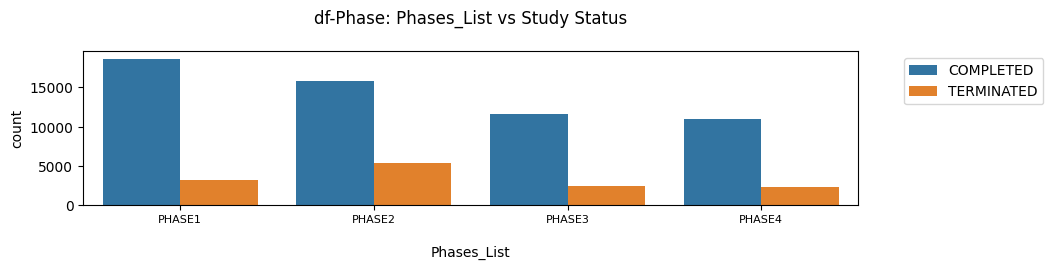

In [887]:
Phases_List = log_fun('Phases_List', df, '', 'list', False, 0, 'PHASE1')

## Adverse


### Adverse_List

df2-Phase 2:
Adverse_List vs Study Status (Termination)



Study_Status_Bin,COMPLETED,TERMINATED
Adverse_List,,
Adv_Death,3271,1031
Adv_None,6716,2595
Adv_Serious,4436,1246
Adv_Unspecified,5673,1625


                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                16982
Model:                          Logit   Df Residuals:                    16978
Method:                           MLE   Df Model:                            3
Date:                Sat, 04 Oct 2025   Pseudo R-squ.:                0.004694
Time:                        16:10:10   Log-Likelihood:                -9605.6
converged:                       True   LL-Null:                       -9650.9
Covariance Type:            nonrobust   LLR p-value:                 1.632e-19
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -0.9461      0.023    -41.678      0.000      -0.991      -0.902
Adv_Death           0.2082      0.056      3.747      0.000       0.099       0.317
Adv_Serious        -0.1951      

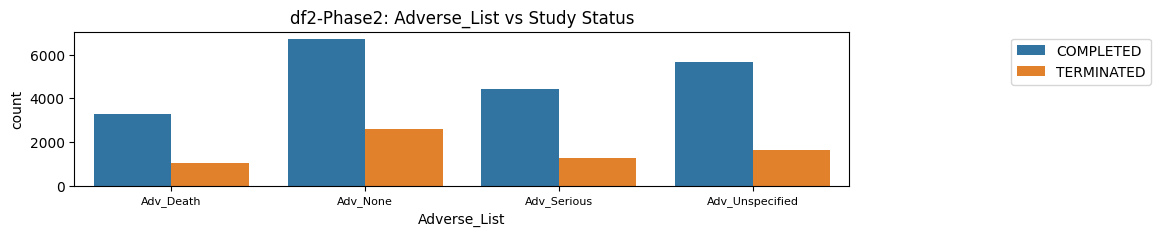

In [ ]:
Adverse_List = log_fun("Adverse_List", dfi, i, 'list', False, 0, 'Adv_None')
# Adverse Death has p value >> 0.05 
# Death does not support adverse from the drug/intervention.
# Corresponds to event noticed in trial but may correspond to patients' state of health due to condition

### Adverse_Counts
Many unique points, in most of features values, are out of main distribution. --> Make pd.cut
log_fun('Adverse_Counts', dfi, i, 'bin', True, 0) --> Error for small values in some levels


df2-Phase 2:
Adverse_Counts vs Study Status


count    16982.000000
mean        34.198151
std        111.617344
min          0.000000
25%          0.000000
50%          0.000000
75%         27.000000
max       3915.000000
Name: Adverse_Counts, dtype: float64


count    1.698200e+04
mean     4.184093e-17
std      1.000029e+00
min     -3.063964e-01
25%     -3.063964e-01
50%     -3.063964e-01
75%     -6.449144e-02
max      3.476983e+01
Name: Adverse_Counts, dtype: float64
                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                16982
Model:                          Logit   Df Residuals:                    16980
Method:                           MLE   Df Model:                            1
Date:                Sat, 04 Oct 2025   Pseudo R-squ.:                 0.01235
Time:                        16:10:10   Log-Likelihood:                -9531.8
converged:                       True   LL-Null:    

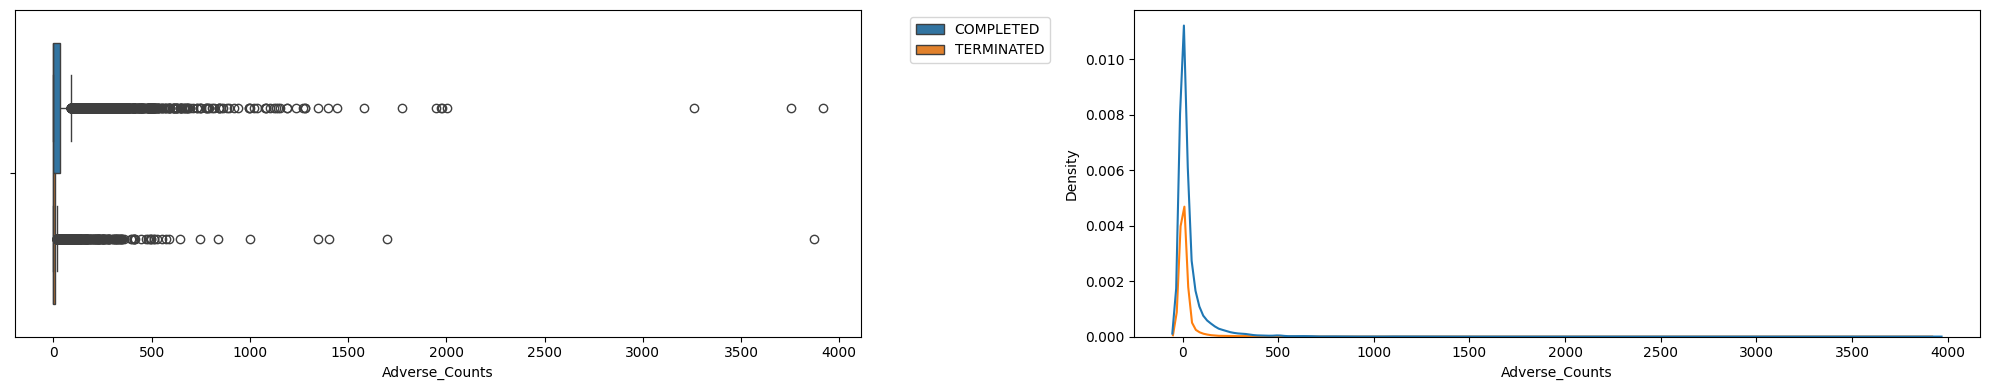

In [848]:
Adverse_Counts = log_fun_cont("Adverse_Counts", dfi, i)  

### Adverse_Counts_Log
- Adverse_Counts despite mostly have the ditribution around small values (0,1,2 etc.) they also have a wide range of values in the remaining distribution.
- That is why they were checked as Log too

df2-Phase 2:
Adverse_Counts_Log vs Study Status


count    16982.000000
mean         1.539292
std          1.952118
min          0.000000
25%          0.000000
50%          0.000000
75%          3.332205
max          8.272826
Name: Adverse_Counts_Log, dtype: float64


count    1.698200e+04
mean     3.347275e-17
std      1.000029e+00
min     -7.885476e-01
25%     -7.885476e-01
50%     -7.885476e-01
75%      9.184717e-01
max      3.449450e+00
Name: Adverse_Counts_Log, dtype: float64
                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                16982
Model:                          Logit   Df Residuals:                    16980
Method:                           MLE   Df Model:                            1
Date:                Sat, 04 Oct 2025   Pseudo R-squ.:                 0.01879
Time:                        16:10:11   Log-Likelihood:                -9469.6
converged:                       True   

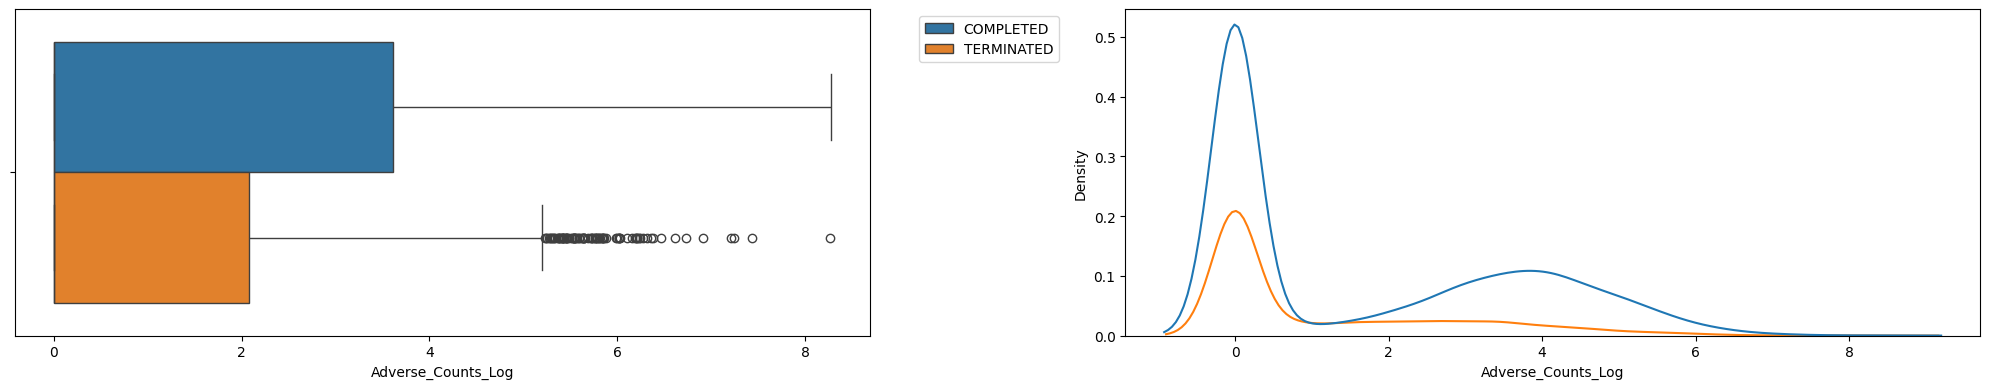

In [849]:
Adverse_Counts_Log = log_fun_cont("Adverse_Counts_Log", dfi, i)

### Adverse_Bin

df2-Phase 2:
Adverse_Bin vs Study Status

p-value: 5.490316677834045e-16 < 0.05

------------------------------------------------------------------------------------------------------------

df2-Phase 2:
Adverse_Bin vs Study Status (Termination)



Study_Status_Bin,COMPLETED,TERMINATED
Adverse_Bin,,
No,6807,2644
Yes,5836,1695


                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                16982
Model:                          Logit   Df Residuals:                    16980
Method:                           MLE   Df Model:                            1
Date:                Sat, 04 Oct 2025   Pseudo R-squ.:                0.003438
Time:                        16:10:11   Log-Likelihood:                -9617.8
converged:                       True   LL-Null:                       -9650.9
Covariance Type:            nonrobust   LLR p-value:                 3.770e-16
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -0.9457      0.023    -41.267      0.000      -0.991      -0.901
Adverse_Bin    -0.2907      0.036     -8.104      0.000      -0.361      -0.220


df2-Phase2: Adverse_Bin p-values:
[const      

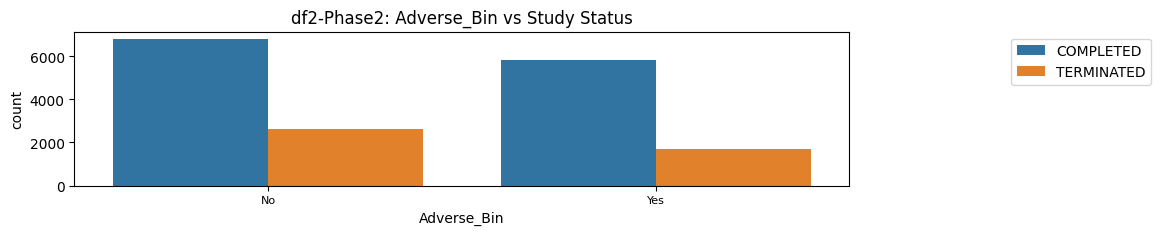

In [850]:
chi2_fun('Adverse_Bin', dfi, i)
#### log_fun
Adverse_Bin = log_fun("Adverse_Bin", dfi, i, 'bin', False, 0)

#### Format
- Risk of sparsity with categ
- Drop _Bin anyway as with the continues variable the question is answered.

In [851]:
Adverse_Counts_aic = fun_compare(i, Adverse_Counts = Adverse_Counts[0], 
                                 Adverse_Counts_Log = Adverse_Counts_Log[0], 
                                 Adverse_Bin = Adverse_Bin[0])
Adverse_Counts_aic

,Adverse_Counts,Adverse_Counts_Log,Adverse_Bin,AIC_min
df2,,,,
Adverse_Counts,[19068.0],[18943.0],[19240.0],Adverse_Counts_Log


In [852]:
dfi = dfi.drop(columns = ['Adverse_Counts', 'Adverse_Bin'], axis = 1)  

### Adverse_System_List


df2-Phase 2:
Adverse_System_List vs Study Status (Termination)



Study_Status_Bin,COMPLETED,TERMINATED
Adverse_System_List,,
"Adv_Syst_Blood, Lymphatic, Endocrine",3112,992
Adv_Syst_Cardio,3102,778
Adv_Syst_Ear,1443,359
Adv_Syst_Eye,2174,548
Adv_Syst_Gastrointestinal,4882,1360
Adv_Syst_General,4678,1323
Adv_Syst_Hepatobiliary,1585,393
Adv_Syst_Immune System,1256,298
Adv_Syst_Infections,4367,1191


                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                16982
Model:                          Logit   Df Residuals:                    16959
Method:                           MLE   Df Model:                           22
Date:                Sat, 04 Oct 2025   Pseudo R-squ.:                 0.01459
Time:                        16:10:12   Log-Likelihood:                -9510.1
converged:                       True   LL-Null:                       -9650.9
Covariance Type:            nonrobust   LLR p-value:                 6.407e-47
                                               coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------
const                                       -0.9410      0.022    -42.750      0.000      -0.984      -0.898
Adv_Syst_Blood, Lymphatic, Endocrine     

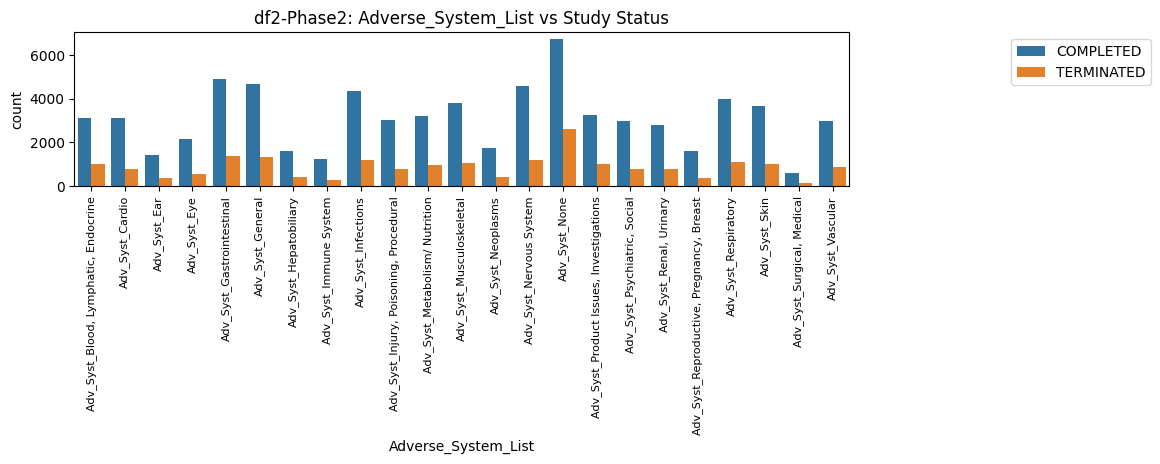

In [853]:
Adverse_System_List = log_fun("Adverse_System_List", dfi, i, 'list', False, 90, 'Adv_Syst_None')

### Adverse_System_Counts
- Different from Adverse_Counts: 
Adverse_Counts = Count of events category (e.g 100 serioues)
Adverse_System_Counts = How many organs.


df2-Phase 2:
Adverse_System_Counts vs Study Status


count    16982.000000
mean         4.860676
std          6.775104
min          0.000000
25%          0.000000
50%          0.000000
75%         10.000000
max         22.000000
Name: Adverse_System_Counts, dtype: float64


count    1.698200e+04
mean    -5.857731e-18
std      1.000029e+00
min     -7.174531e-01
25%     -7.174531e-01
50%     -7.174531e-01
75%      7.585825e-01
max      2.529825e+00
Name: Adverse_System_Counts, dtype: float64
                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                16982
Model:                          Logit   Df Residuals:                    16980
Method:                           MLE   Df Model:                            1
Date:                Sat, 04 Oct 2025   Pseudo R-squ.:                0.004023
Time:                        16:10:12   Log-Likelihood:                -9612.1
converged:                     

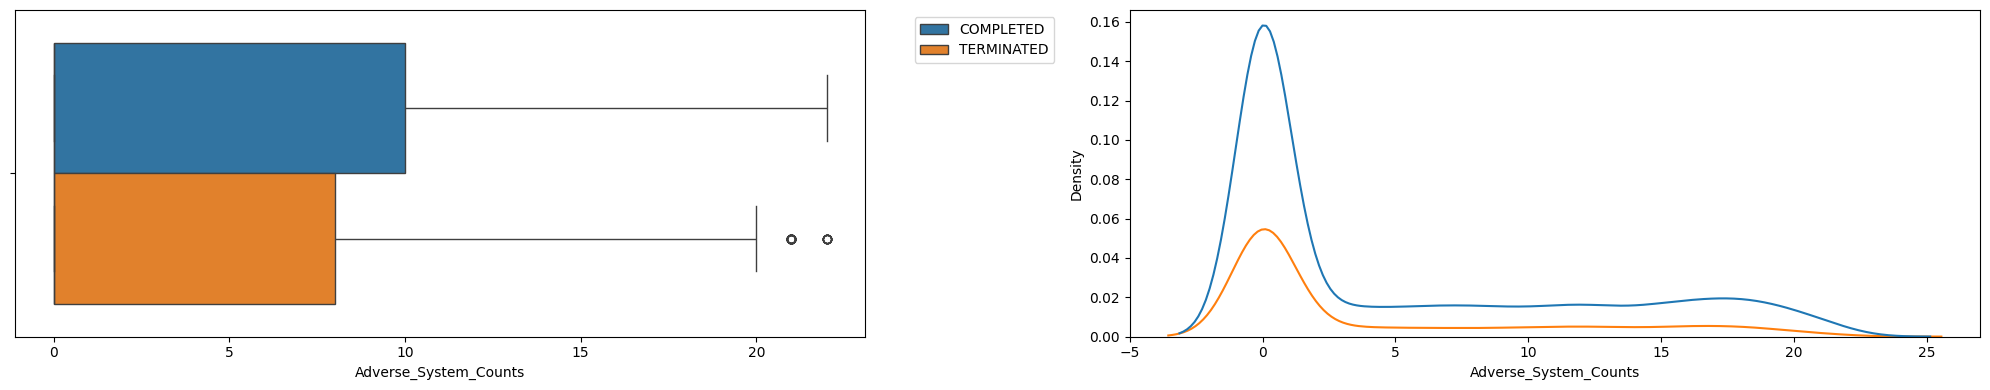

In [854]:
Adverse_System_Counts = log_fun_cont("Adverse_System_Counts", dfi, i)

### Adverse_System_Counts_Log
- Adverse_System_Counts despite mostly have the ditribution around small values (0,1,2 etc.) they also have a wide range of values in the remaining distribution.
- That is why they were checked as Log too

df2-Phase 2:
Adverse_System_Counts_Log vs Study Status


count    16982.000000
mean         1.022917
std          1.223458
min          0.000000
25%          0.000000
50%          0.000000
75%          2.397895
max          3.135494
Name: Adverse_System_Counts_Log, dtype: float64


count    1.698200e+04
mean     1.464433e-17
std      1.000029e+00
min     -8.361114e-01
25%     -8.361114e-01
50%     -8.361114e-01
75%      1.123879e+00
max      1.726777e+00
Name: Adverse_System_Counts_Log, dtype: float64
                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                16982
Model:                          Logit   Df Residuals:                    16980
Method:                           MLE   Df Model:                            1
Date:                Sat, 04 Oct 2025   Pseudo R-squ.:                0.004043
Time:                        16:10:13   Log-Likelihood:                -9611.9
converged:         

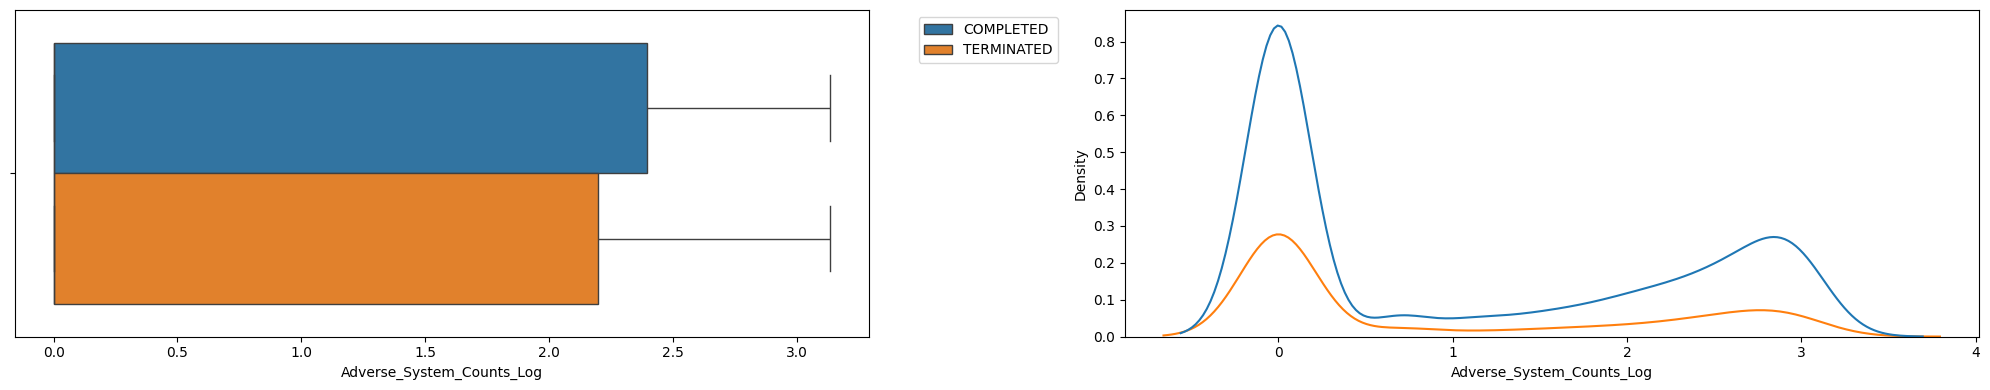

In [855]:
Adverse_System_Counts_Log = log_fun_cont("Adverse_System_Counts_Log", dfi, i)

### Adverse_System_Categ

df2-Phase 2:
Adverse_System_Categ vs Study Status

p-value: 9.57031614910276e-19 < 0.05

------------------------------------------------------------------------------------------------------------

df2-Phase 2:
Adverse_System_Categ vs Study Status (Termination)



Study_Status_Bin,COMPLETED,TERMINATED
Adverse_System_Categ,,
0–1,7135,2782
2–22,5508,1557


                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                16982
Model:                          Logit   Df Residuals:                    16980
Method:                           MLE   Df Model:                            1
Date:                Sat, 04 Oct 2025   Pseudo R-squ.:                0.004108
Time:                        16:10:14   Log-Likelihood:                -9611.3
converged:                       True   LL-Null:                       -9650.9
Covariance Type:            nonrobust   LLR p-value:                 5.334e-19
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   -0.9418      0.022    -42.137      0.000      -0.986      -0.898
Adverse_System_Categ    -0.3216      0.036     -8.840      0.000      -0.393      -0.250


df2-Phase2

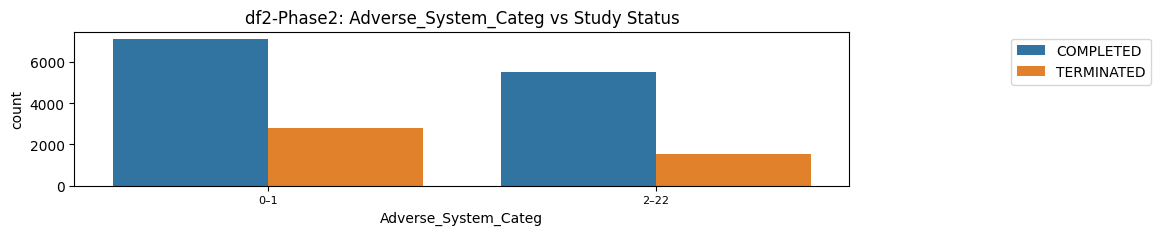

In [856]:
chi2_fun('Adverse_System_Categ', dfi, i)

#### log_fun
Adverse_System_Categ = log_fun('Adverse_System_Categ', dfi, i, 'bin', True, 0)


dfi = dfi.drop(columns = ['Adverse_Counts', 'Adverse_Bin'], axis = 1)

#### Format
- Risk of Sparsity with Categ
- Similar information with Adverse_Counts

In [857]:
Adverse_System_Counts_aic = fun_compare(i, 
                                        Adverse_System_Counts = Adverse_System_Counts[0], 
                                        Adverse_System_Counts_Log = Adverse_System_Counts_Log[0],
                                        ) 
Adverse_System_Counts_aic

,Adverse_System_Counts,Adverse_System_Counts_Log,AIC_min
df2,,,
Adverse_System_Counts,[19228.0],[19228.0],Adverse_System_Counts


In [858]:
dfi = dfi.drop(columns = ['Adverse_System_Counts', 'Adverse_System_Categ'], axis = 1)

## Placebo_Bin

df2-Phase 2:
Placebo_Bin vs Study Status

p-value: 5.065867122658814e-19 < 0.05

------------------------------------------------------------------------------------------------------------

df2-Phase 2:
Placebo_Bin vs Study Status (Termination)



Study_Status_Bin,COMPLETED,TERMINATED
Placebo_Bin,,
No,7944,3052
Yes,4699,1287


                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                16982
Model:                          Logit   Df Residuals:                    16980
Method:                           MLE   Df Model:                            1
Date:                Sat, 04 Oct 2025   Pseudo R-squ.:                0.004207
Time:                        16:10:14   Log-Likelihood:                -9610.3
converged:                       True   LL-Null:                       -9650.9
Covariance Type:            nonrobust   LLR p-value:                 2.038e-19
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -0.9567      0.021    -44.921      0.000      -0.998      -0.915
Placebo_Bin    -0.3384      0.038     -8.907      0.000      -0.413      -0.264


df2-Phase2: Placebo_Bin p-values:
[const      

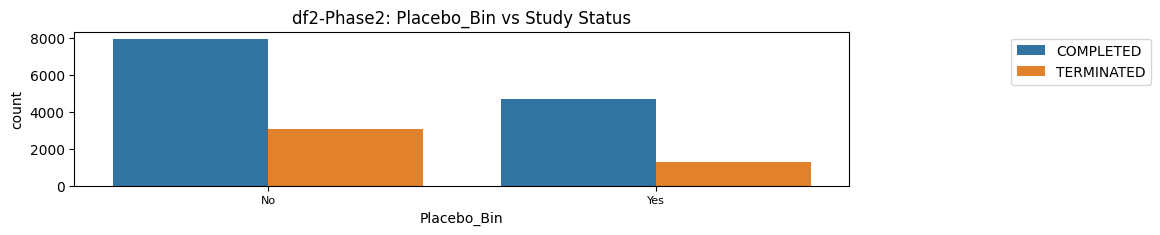

In [859]:
chi2_fun("Placebo_Bin", dfi, i)
### log_fun
Placebo_Bin = log_fun('Placebo_Bin', dfi, i, 'bin', False, 0)

## Standard_Care_Bin 

df2-Phase 2:
Standard_Care_Bin vs Study Status

p-value: 1.958040975189623e-12 < 0.05

------------------------------------------------------------------------------------------------------------

df2-Phase 2:
Standard_Care_Bin vs Study Status (Termination)



Study_Status_Bin,COMPLETED,TERMINATED
Standard_Care_Bin,,
No,12159,4061
Yes,484,278


                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                16982
Model:                          Logit   Df Residuals:                    16980
Method:                           MLE   Df Model:                            1
Date:                Sat, 04 Oct 2025   Pseudo R-squ.:                0.002413
Time:                        16:10:14   Log-Likelihood:                -9627.6
converged:                       True   LL-Null:                       -9650.9
Covariance Type:            nonrobust   LLR p-value:                 8.848e-12
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -1.0967      0.018    -60.507      0.000      -1.132      -1.061
Standard_Care_Bin     0.5424      0.077      7.008      0.000       0.391       0.694


df2-Phase2: Standard_C

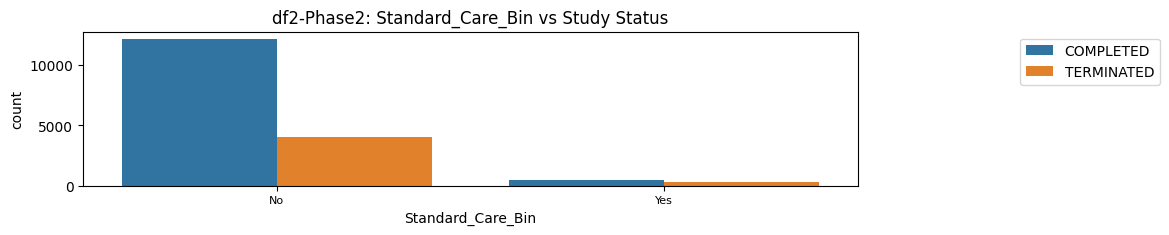

In [860]:
chi2_fun("Standard_Care_Bin", dfi, i)
### log_fun
Standard_Care_Bin = log_fun('Standard_Care_Bin', dfi, i, 'bin', False, 0)

## Healthy_Bin

df2-Phase 2:
Healthy_Bin vs Study Status

p-value: 6.106633973208882e-32 < 0.05

------------------------------------------------------------------------------------------------------------

df2-Phase 2:
Healthy_Bin vs Study Status (Termination)



Study_Status_Bin,COMPLETED,TERMINATED
Healthy_Bin,,
No,11134,4095
Yes,1509,244


                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                16982
Model:                          Logit   Df Residuals:                    16980
Method:                           MLE   Df Model:                            1
Date:                Sat, 04 Oct 2025   Pseudo R-squ.:                0.008077
Time:                        16:10:15   Log-Likelihood:                -9573.0
converged:                       True   LL-Null:                       -9650.9
Covariance Type:            nonrobust   LLR p-value:                 8.913e-36
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -1.0002      0.018    -54.728      0.000      -1.036      -0.964
Healthy_Bin    -0.8222      0.071    -11.518      0.000      -0.962      -0.682


df2-Phase2: Healthy_Bin p-values:
[const      

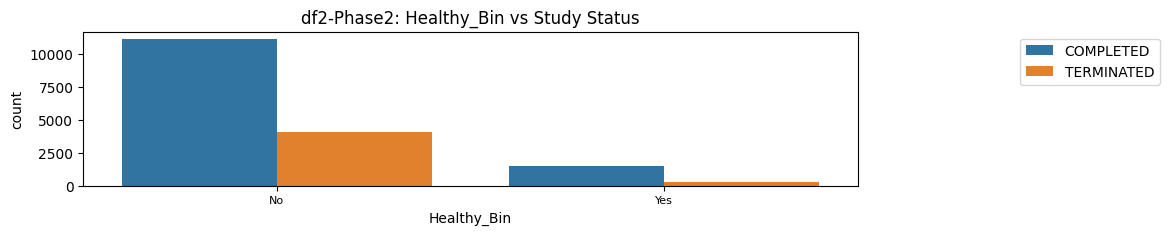

In [861]:
chi2_fun("Healthy_Bin", dfi, i)
### log_fun
Healthy_Bin = log_fun('Healthy_Bin', dfi, i, 'bin', False, 0)

## Covid_19_Bin

df2-Phase 2:
Covid_19_Bin vs Study Status

p-value: 8.563424600439296e-10 < 0.05

------------------------------------------------------------------------------------------------------------

df2-Phase 2:
Covid_19_Bin vs Study Status (Termination)



Study_Status_Bin,COMPLETED,TERMINATED
Covid_19_Bin,,
No,12324,4149
Yes,319,190


                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                16982
Model:                          Logit   Df Residuals:                    16980
Method:                           MLE   Df Model:                            1
Date:                Sat, 04 Oct 2025   Pseudo R-squ.:                0.001831
Time:                        16:10:15   Log-Likelihood:                -9633.3
converged:                       True   LL-Null:                       -9650.9
Covariance Type:            nonrobust   LLR p-value:                 2.776e-09
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -1.0887      0.018    -60.654      0.000      -1.124      -1.053
Covid_19_Bin     0.5707      0.093      6.111      0.000       0.388       0.754


df2-Phase2: Covid_19_Bin p-values:
[const 

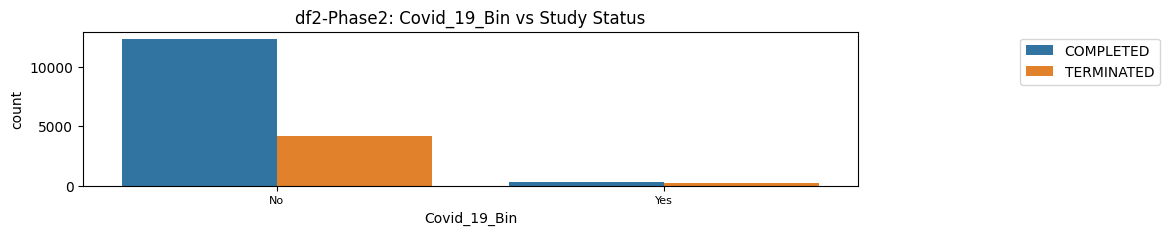

In [862]:
chi2_fun("Covid_19_Bin", dfi, i)
### log_fun
Covid_19_Bin = log_fun('Covid_19_Bin', dfi, i, 'bin', False, 0)

### Format
- Similar information with Respiratory Conditions_Detail

In [863]:
dfi = dfi.drop(columns = ['Covid_19_Bin'])

## Conditions_Detail_List

df2-Phase 2:
Conditions_Detail_List vs Study Status (Termination)



Study_Status_Bin,COMPLETED,TERMINATED
Conditions_Detail_List,,
Bacterial Infections and Mycoses,1403,440
Cardiovascular,1045,382
Chemical Disorders,275,72
Cond_Detail_Other,547,132
"Digestive System, Nutritional, Metabolic",2525,873
Endocrine System,855,288
Eye,382,96
"Health Care, Therapeutics",220,55
"Hemic, Lymphatic, Immune System",2167,825


                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                16982
Model:                          Logit   Df Residuals:                    16960
Method:                           MLE   Df Model:                           21
Date:                Sat, 04 Oct 2025   Pseudo R-squ.:                 0.02023
Time:                        16:10:15   Log-Likelihood:                -9455.7
converged:                       True   LL-Null:                       -9650.9
Covariance Type:            nonrobust   LLR p-value:                 8.856e-70
                                                      coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------------
const                                              -1.3931      0.043    -32.215      0.000      -1.478      -1.308
Bacterial Infections

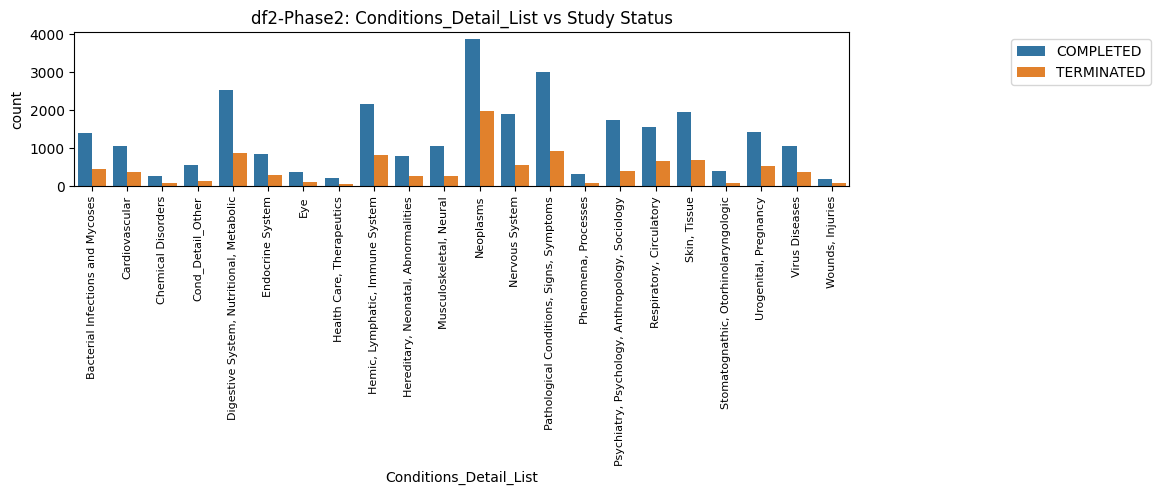

In [864]:
Conditions_Detail_List = log_fun("Conditions_Detail_List", dfi, i, 'list', False, 90, 'Cond_Detail_Other' )

## Funder_Industry_Bin

df2-Phase 2:
Funder_Industry_Bin vs Study Status (Termination)



Study_Status_Bin,COMPLETED,TERMINATED
Funder_Industry_Bin,,
FUNDER_OTHER,6925,2619
INDUSTRY,5718,1720


                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                16982
Model:                          Logit   Df Residuals:                    16980
Method:                           MLE   Df Model:                            1
Date:                Sat, 04 Oct 2025   Pseudo R-squ.:                0.002133
Time:                        16:10:16   Log-Likelihood:                -9630.3
converged:                       True   LL-Null:                       -9650.9
Covariance Type:            nonrobust   LLR p-value:                 1.389e-10
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  -0.9724      0.023    -42.387      0.000      -1.017      -0.927
Funder_Industry_Bin    -0.2289      0.036     -6.391      0.000      -0.299      -0.159


df2-Phase2: Fu

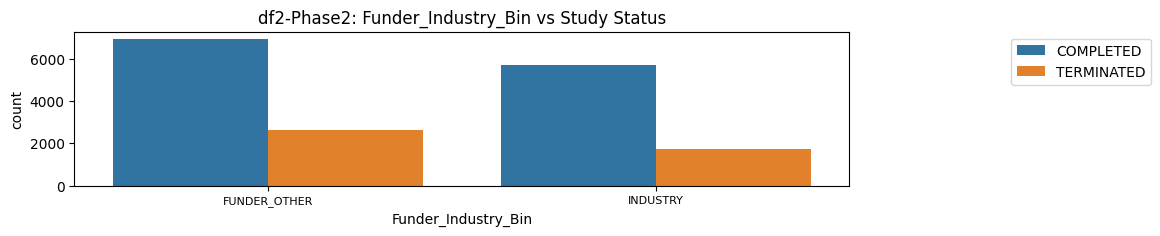

In [865]:
Funder_Industry_Bin = log_fun("Funder_Industry_Bin", dfi, i, 'bin', False, 0, 'FUNDER_OTHER')

## Age_List

df2-Phase 2:
Age_List vs Study Status (Termination)



Study_Status_Bin,COMPLETED,TERMINATED
Age_List,,
ADULT,11947,4148
CHILD,1583,442
OLDER_ADULT,10400,3846


                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                16982
Model:                          Logit   Df Residuals:                    16979
Method:                           MLE   Df Model:                            2
Date:                Sat, 04 Oct 2025   Pseudo R-squ.:                0.005482
Time:                        16:10:16   Log-Likelihood:                -9598.0
converged:                       True   LL-Null:                       -9650.9
Covariance Type:            nonrobust   LLR p-value:                 1.050e-23
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -1.4106      0.083    -16.950      0.000      -1.574      -1.247
ADULT          -0.1440      0.093     -1.550      0.121      -0.326       0.038
OLDER_ADULT     0.5581      0.059      9.488    

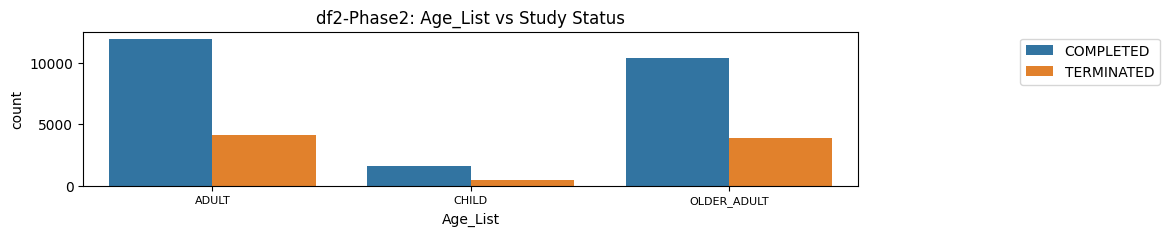

In [866]:
Age_List = log_fun("Age_List", dfi, i, 'list', False, 0, 'CHILD')

## Sex_List


df2-Phase 2:
Sex_List vs Study Status (Termination)



Study_Status_Bin,COMPLETED,TERMINATED
Sex_List,,
ALL,11115,3878
FEMALE,1034,286
MALE,494,175


                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                16982
Model:                          Logit   Df Residuals:                    16979
Method:                           MLE   Df Model:                            2
Date:                Sat, 04 Oct 2025   Pseudo R-squ.:               0.0006092
Time:                        16:10:17   Log-Likelihood:                -9645.1
converged:                       True   LL-Null:                       -9650.9
Covariance Type:            nonrobust   LLR p-value:                  0.002797
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.0530      0.019    -56.459      0.000      -1.090      -1.016
FEMALE        -0.2322      0.069     -3.347      0.001      -0.368      -0.096
MALE           0.0153      0.090      0.170      0.8

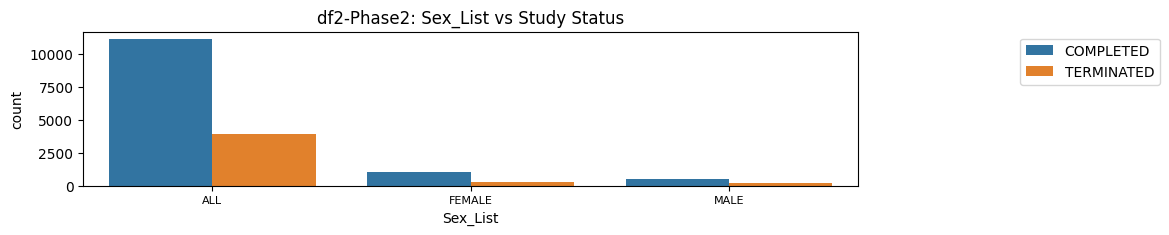

In [867]:
Sex_List = log_fun("Sex_List", dfi, i, 'list', False, 0, 'ALL')

## Study Design

### Allocation_List

df2-Phase 2:
Allocation_List vs Study Status (Termination)



Study_Status_Bin,COMPLETED,TERMINATED
Allocation_List,,
NA_RANDOMIZED,3483,1572
NON_RANDOMIZED,868,367
RANDOMIZED,8292,2400


                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                16982
Model:                          Logit   Df Residuals:                    16979
Method:                           MLE   Df Model:                            2
Date:                Sat, 04 Oct 2025   Pseudo R-squ.:                0.007509
Time:                        16:10:17   Log-Likelihood:                -9578.5
converged:                       True   LL-Null:                       -9650.9
Covariance Type:            nonrobust   LLR p-value:                 3.367e-32
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -0.7956      0.030    -26.183      0.000      -0.855      -0.736
NON_RANDOMIZED    -0.0653      0.069     -0.943      0.346      -0.201       0.070
RANDOMIZED        -0.4442      0.038

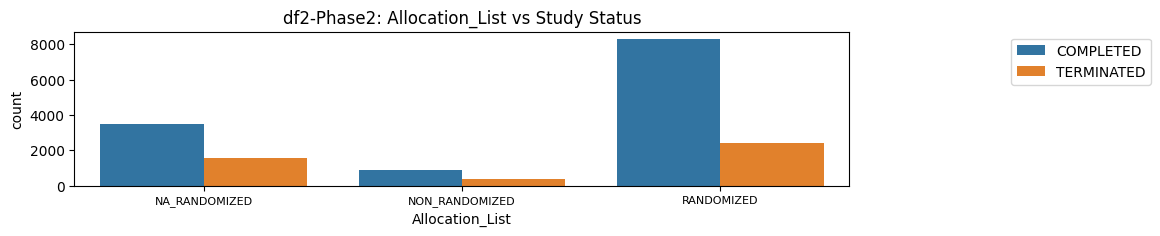

In [868]:
Allocation_List = log_fun("Allocation_List", dfi, i, 'list', False, 0, 'NA_RANDOMIZED')

### Masking_List


df2-Phase 2:
Masking_List vs Study Status (Termination)



Study_Status_Bin,COMPLETED,TERMINATED
Masking_List,,
DOUBLE,1836,453
MASK_NONE,6058,2622
QUADRUPLE,2758,709
SINGLE,679,161
TRIPLE,1312,394


                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                16982
Model:                          Logit   Df Residuals:                    16977
Method:                           MLE   Df Model:                            4
Date:                Sat, 04 Oct 2025   Pseudo R-squ.:                 0.01099
Time:                        16:10:17   Log-Likelihood:                -9544.9
converged:                       True   LL-Null:                       -9650.9
Covariance Type:            nonrobust   LLR p-value:                 9.694e-45
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.8375      0.023    -35.825      0.000      -0.883      -0.792
DOUBLE        -0.5620      0.057     -9.785      0.000      -0.675      -0.449
QUADRUPLE     -0.5210      0.048    -10.817      0.0

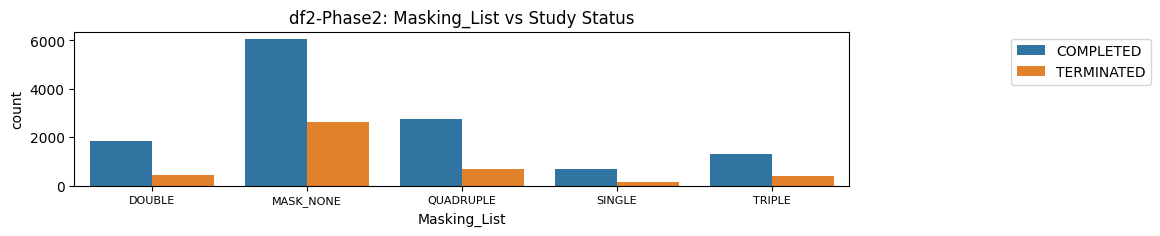

In [869]:
Masking_List = log_fun("Masking_List", dfi, i, 'list', False, 0, 'MASK_NONE')

### Masking_Detail_List

df2-Phase 2:
Masking_Detail_List vs Study Status (Termination)



Study_Status_Bin,COMPLETED,TERMINATED
Masking_Detail_List,,
CARE_PROVIDER,3705,993
INVESTIGATOR,5639,1509
MASK_DET_NONE,6058,2622
OUTCOMES_ASSESSOR,3840,967
PARTICIPANT,6135,1616


                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                16982
Model:                          Logit   Df Residuals:                    16977
Method:                           MLE   Df Model:                            4
Date:                Sat, 04 Oct 2025   Pseudo R-squ.:                0.009646
Time:                        16:10:18   Log-Likelihood:                -9557.8
converged:                       True   LL-Null:                       -9650.9
Covariance Type:            nonrobust   LLR p-value:                 3.482e-39
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -0.8623      0.023    -37.529      0.000      -0.907      -0.817
CARE_PROVIDER         0.1440      0.064      2.260      0.024       0.019       0.269
INVESTIGATOR          0.

KeyboardInterrupt: 

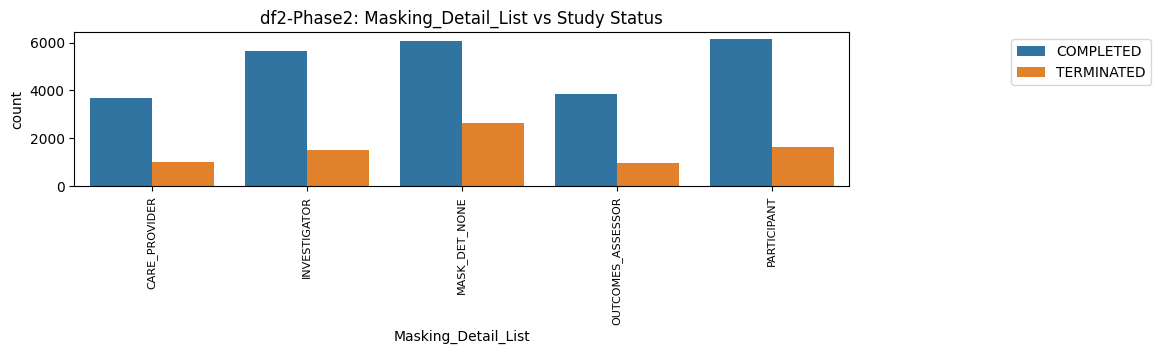

In [870]:
Masking_Detail_List = log_fun("Masking_Detail_List", dfi, i, 'list', False, 90, 'MASK_DET_NONE')


### Primary_Purpose_List


df2-Phase 2:
Primary_Purpose_List vs Study Status (Termination)



Study_Status_Bin,COMPLETED,TERMINATED
Primary_Purpose_List,,
BASIC_SCIENCE,209,77
DIAGNOSTIC,220,101
PREVENTION,1024,199
PRIM_PURP_OTHER,336,60
SUPPORTIVE_CARE,265,90
TREATMENT,10589,3812


                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                16982
Model:                          Logit   Df Residuals:                    16976
Method:                           MLE   Df Model:                            5
Date:                Sat, 04 Oct 2025   Pseudo R-squ.:                0.005098
Time:                        01:10:03   Log-Likelihood:                -9601.7
converged:                       True   LL-Null:                       -9650.9
Covariance Type:            nonrobust   LLR p-value:                 1.150e-19
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -1.7226      0.140    -12.292      0.000      -1.997      -1.448
BASIC_SCIENCE       0.7217      0.193      3.730      0.000       0.343       1.101
DIAGNOSTIC          0.9438      

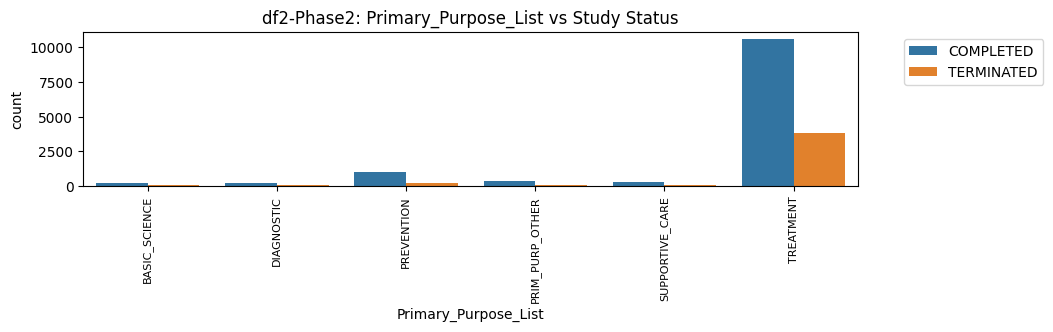

In [ ]:
Primary_Purpose_List = log_fun("Primary_Purpose_List", dfi, i, 'list', False, 90, 'PRIM_PURP_OTHER')

## Arms

### Arm_Counts

df2-Phase 2:
Arm_Counts vs Study Status


count    16982.000000
mean         2.261630
std          1.535068
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         24.000000
Name: Arm_Counts, dtype: float64


count    1.698200e+04
mean    -9.644335e-17
std      1.000029e+00
min     -8.218968e-01
25%     -8.218968e-01
50%     -1.704405e-01
75%      4.810158e-01
max      1.416160e+01
Name: Arm_Counts, dtype: float64
                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                16982
Model:                          Logit   Df Residuals:                    16980
Method:                           MLE   Df Model:                            1
Date:                Sat, 04 Oct 2025   Pseudo R-squ.:                0.009328
Time:                        01:10:04   Log-Likelihood:                -9560.9
converged:                       True   LL-Null:                

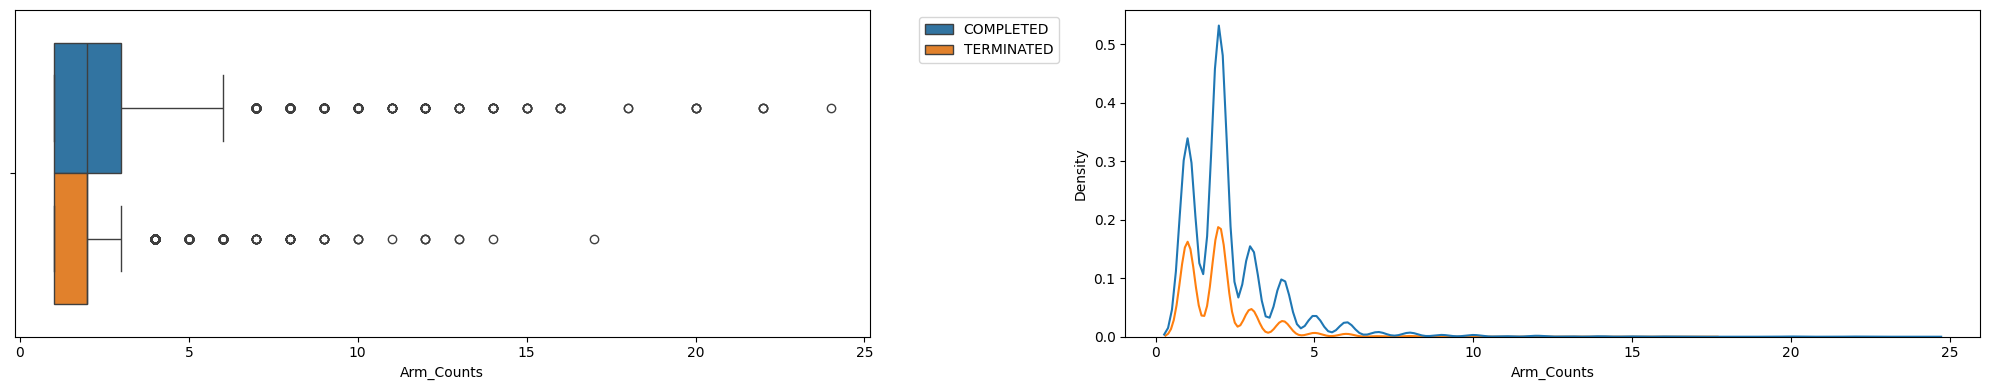

In [ ]:
Arm_Counts = Arm_Counts = log_fun_cont("Arm_Counts", dfi, i)

### Arm_Counts_Log
- Arm_Counts despite mostly have the ditribution around small values (0,1,2 etc.) they also have a wide range of values in the remaining distribution.
- That is why they were checked as Log too

df2-Phase 2:
Arm_Counts vs Study Status


count    16982.000000
mean         2.261630
std          1.535068
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         24.000000
Name: Arm_Counts, dtype: float64


count    1.698200e+04
mean    -9.644335e-17
std      1.000029e+00
min     -8.218968e-01
25%     -8.218968e-01
50%     -1.704405e-01
75%      4.810158e-01
max      1.416160e+01
Name: Arm_Counts, dtype: float64
                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                16982
Model:                          Logit   Df Residuals:                    16980
Method:                           MLE   Df Model:                            1
Date:                Sat, 04 Oct 2025   Pseudo R-squ.:                0.009328
Time:                        01:10:04   Log-Likelihood:                -9560.9
converged:                       True   LL-Null:                

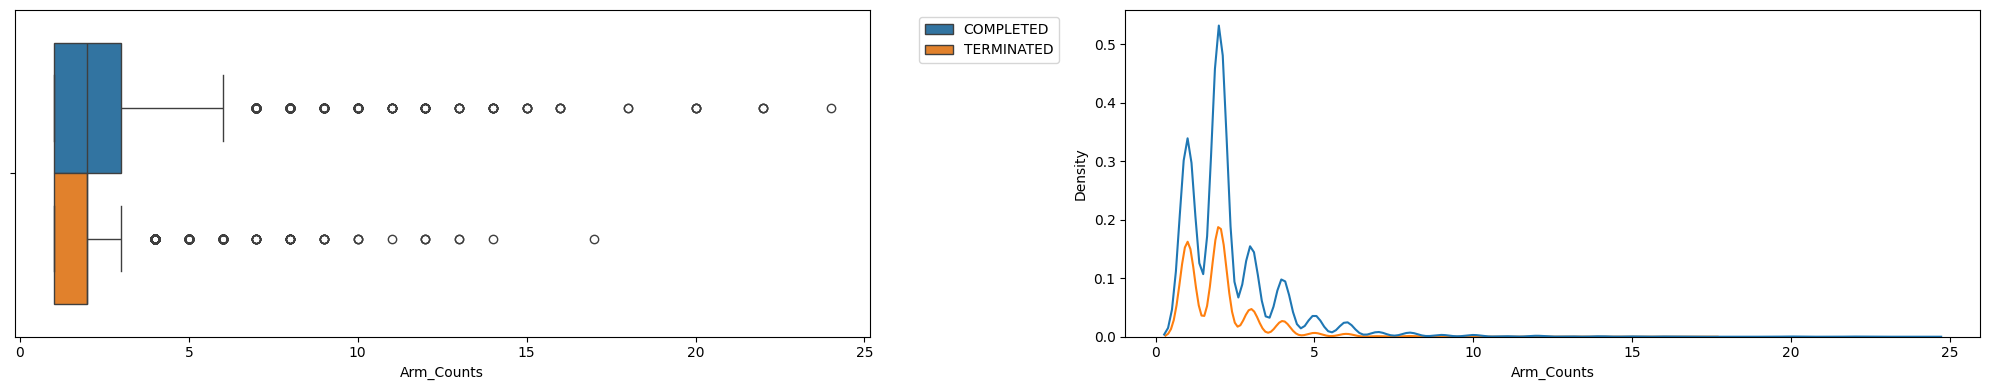

In [ ]:
Arm_Counts_Log = Arm_Counts_Log = log_fun_cont("Arm_Counts", dfi, i)

### Arm_Categ

df2-Phase 2:
Arm_Categ vs Study Status

p-value: 1.1695281825406406e-24 < 0.05

------------------------------------------------------------------------------------------------------------

df2-Phase 2:
Arm_Categ vs Study Status (Termination)



Study_Status_Bin,COMPLETED,TERMINATED
Arm_Categ,,
1–2,9071,3458
3–43,3572,881


                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                16982
Model:                          Logit   Df Residuals:                    16980
Method:                           MLE   Df Model:                            1
Date:                Sat, 04 Oct 2025   Pseudo R-squ.:                0.005671
Time:                        01:10:05   Log-Likelihood:                -9596.2
converged:                       True   LL-Null:                       -9650.9
Covariance Type:            nonrobust   LLR p-value:                 1.282e-25
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.9644      0.020    -48.254      0.000      -1.004      -0.925
Arm_Categ     -0.4355      0.043    -10.223      0.000      -0.519      -0.352


df2-Phase2: Arm_Categ p-values:
[const        0.00

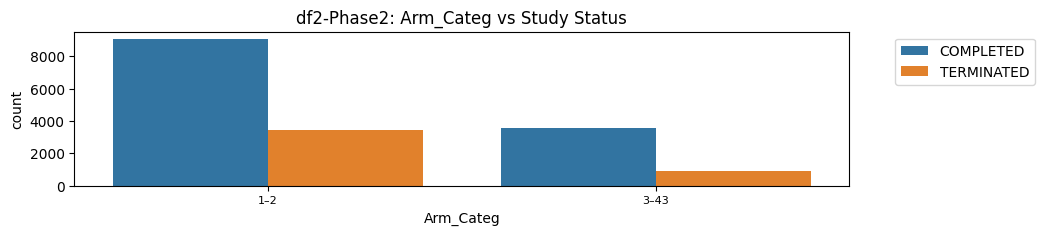

In [ ]:
chi2_fun('Arm_Categ', dfi, i)
#### Log_Fun
Arm_Categ = log_fun('Arm_Categ', dfi, i, 'bin', True, 0)

#### Format
- Risk of Sparsity with categ

In [ ]:
Arm_Counts_aic = fun_compare(i, Arm_Counts = Arm_Counts[0], Arm_Counts_Log = Arm_Counts_Log[0])
Arm_Counts_aic

,Arm_Counts,Arm_Counts_Log,AIC_min
df2,,,
Arm_Counts,[19126.0],[19126.0],Arm_Counts


In [ ]:
dfi = dfi.drop(columns = ['Arm_Counts', 'Arm_Categ'], axis = 1)

## Intervention_Model_List

df2-Phase 2:
Intervention_Model_List vs Study Status (Termination)



Study_Status_Bin,COMPLETED,TERMINATED
Intervention_Model_List,,
CROSSOVER,803,179
FACTORIAL,77,22
PARALLEL,7775,2338
SEQUENTIAL,225,114
SINGLE_GROUP,3763,1686


                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                16982
Model:                          Logit   Df Residuals:                    16977
Method:                           MLE   Df Model:                            4
Date:                Sat, 04 Oct 2025   Pseudo R-squ.:                0.007941
Time:                        01:10:05   Log-Likelihood:                -9574.3
converged:                       True   LL-Null:                       -9650.9
Covariance Type:            nonrobust   LLR p-value:                 4.034e-32
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.8028      0.029    -27.392      0.000      -0.860      -0.745
CROSSOVER     -0.6982      0.088     -7.962      0.000      -0.870      -0.526
FACTORIAL     -0.4496      0.243     -1.847      0.0

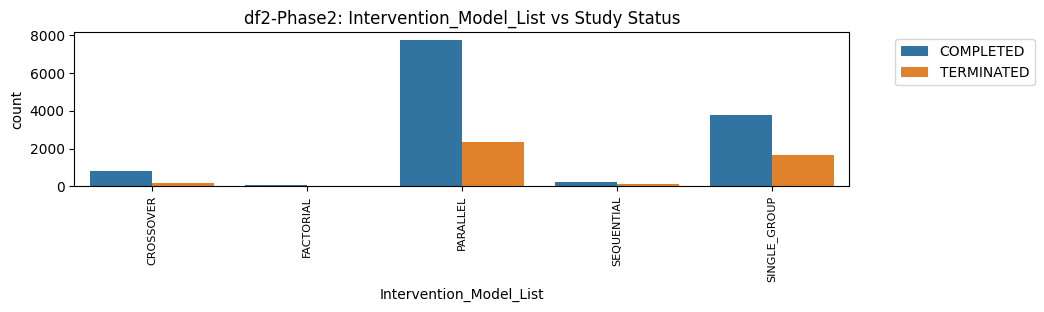

In [ ]:
Intervention_Model_List = log_fun("Intervention_Model_List", dfi, i, 'list', False, 90, 'SINGLE_GROUP' )

## Intervention_Type_List

df2-Phase 2:
Intervention_Type_List vs Study Status (Termination)



Study_Status_Bin,COMPLETED,TERMINATED
Intervention_Type_List,,
BEHAVIORAL,287,50
BIOLOGICAL,1133,423
DEVICE,363,133
DIETARY_SUPPLEMENT,249,52
DRUG,9531,3384
INTERV_OTHER,1437,515
INTERV_UNSPES,416,218
PROCEDURE,380,176


                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                16982
Model:                          Logit   Df Residuals:                    16974
Method:                           MLE   Df Model:                            7
Date:                Sat, 04 Oct 2025   Pseudo R-squ.:                0.004186
Time:                        01:10:06   Log-Likelihood:                -9610.5
converged:                       True   LL-Null:                       -9650.9
Covariance Type:            nonrobust   LLR p-value:                 9.450e-15
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 -1.2301      0.045    -27.574      0.000      -1.318      -1.143
BEHAVIORAL            -0.5971      0.156     -3.826      0.000      -0.903      -0.291
BIOLOGICAL          

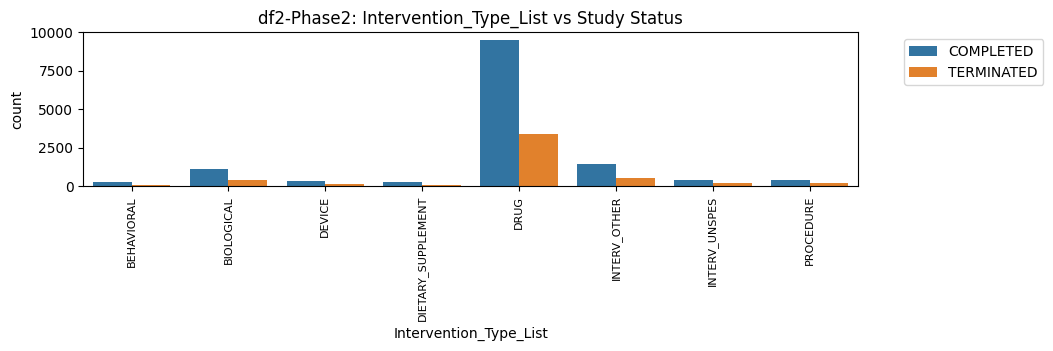

In [ ]:
Intervention_Type_List = log_fun("Intervention_Type_List", dfi, i, 'list', False, 90, 'INTERV_OTHER')

## Intervention_Type_Counts


df2-Phase 2:
Intervention_Type_Counts vs Study Status


count    16982.000000
mean         1.103934
std          0.346396
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          5.000000
Name: Intervention_Type_Counts, dtype: float64


count    1.698200e+04
mean     1.619244e-16
std      1.000029e+00
min     -3.000512e-01
25%     -3.000512e-01
50%     -3.000512e-01
75%     -3.000512e-01
max      1.124776e+01
Name: Intervention_Type_Counts, dtype: float64
                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                16982
Model:                          Logit   Df Residuals:                    16980
Method:                           MLE   Df Model:                            1
Date:                Sat, 04 Oct 2025   Pseudo R-squ.:                0.003232
Time:                        01:10:06   Log-Likelihood:                -9619.7
converged:            

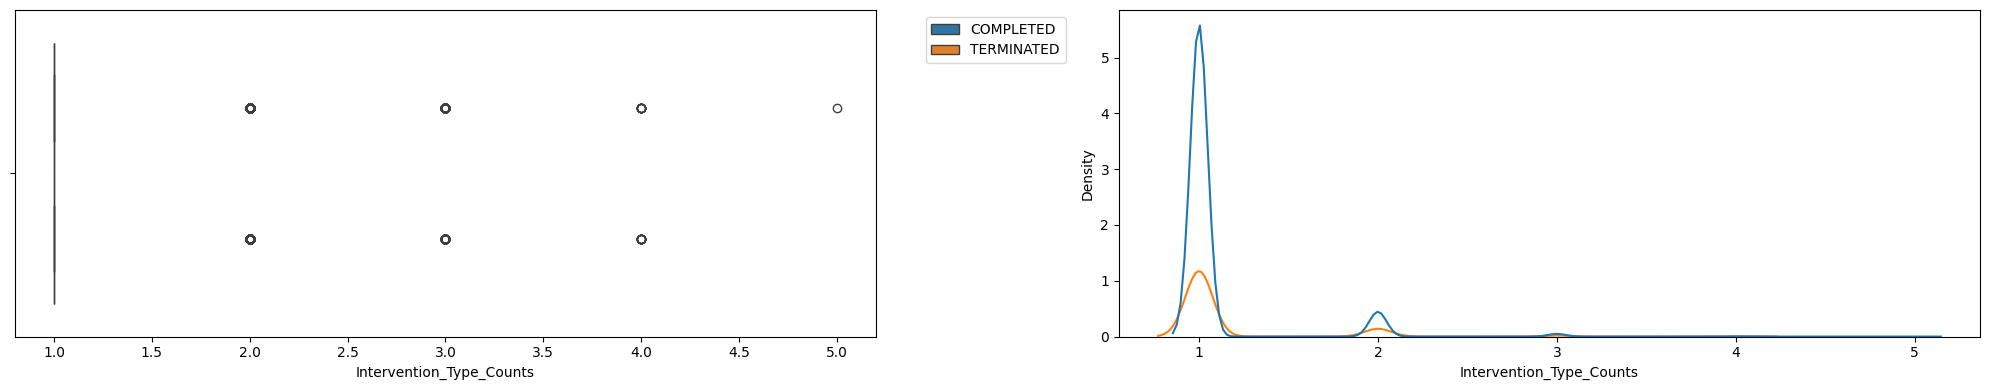

In [ ]:
Intervention_Type_Counts = log_fun_cont("Intervention_Type_Counts", dfi, i)

## Intervention_Type_Categ

df2-Phase 2:
Intervention_Type_Categ vs Study Status

p-value: 9.284532466875916e-15 < 0.05

------------------------------------------------------------------------------------------------------------

df2-Phase 2:
Intervention_Type_Categ vs Study Status (Termination)



Study_Status_Bin,COMPLETED,TERMINATED
Intervention_Type_Categ,,
1,11610,3813
2–5,1033,526


                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                16982
Model:                          Logit   Df Residuals:                    16980
Method:                           MLE   Df Model:                            1
Date:                Sat, 04 Oct 2025   Pseudo R-squ.:                0.002970
Time:                        01:10:07   Log-Likelihood:                -9622.3
converged:                       True   LL-Null:                       -9650.9
Covariance Type:            nonrobust   LLR p-value:                 3.706e-14
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                      -1.1134      0.019    -59.653      0.000      -1.150      -1.077
Intervention_Type_Categ     0.4385      0.057      7.731      0.000       0.327       0.550


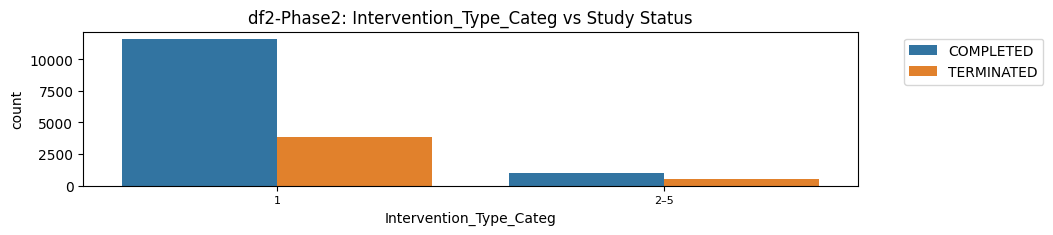

In [ ]:
chi2_fun('Intervention_Type_Categ', dfi, i)
#### log_fun
Intervention_Type_Categ = log_fun('Intervention_Type_Categ', dfi, i, 'bin', True, 0)

#### Format
- Almost all distribution is at 1. Very small sample size except 1. No need for analysis.
- That is why _Log was not checks too.
- As categorical there is parsity risk.

In [ ]:
Intervention_Type_Counts_aic = fun_compare(i, Intervention_Type_Counts = Intervention_Type_Counts[0], 
                                           Intervention_Type_Categ = Intervention_Type_Categ[0])
Intervention_Type_Counts_aic

,Intervention_Type_Counts,Intervention_Type_Categ,AIC_min
df2,,,
Intervention_Type_Counts,[19243.0],[19249.0],Intervention_Type_Counts


In [ ]:
dfi = dfi.drop(columns = ['Intervention_Type_Counts', 'Intervention_Type_Categ'], axis = 1)

## Intervention_Route

### Intervention_Route_List

df2-Phase 2:
Intervention_Route_List vs Study Status (Termination)



Study_Status_Bin,COMPLETED,TERMINATED
Intervention_Route_List,,
Injection,4836,1738
Inter_Route_Other,4902,1692
Oral,2127,636
Surgical,1378,614
Topical,1980,734


                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                16982
Model:                          Logit   Df Residuals:                    16977
Method:                           MLE   Df Model:                            4
Date:                Sat, 04 Oct 2025   Pseudo R-squ.:                0.002576
Time:                        01:10:07   Log-Likelihood:                -9626.1
converged:                       True   LL-Null:                       -9650.9
Covariance Type:            nonrobust   LLR p-value:                 4.121e-10
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.1197      0.026    -43.462      0.000      -1.170      -1.069
Injection      0.0509      0.036      1.403      0.161      -0.020       0.122
Oral          -0.1551      0.049     -3.156      0.0

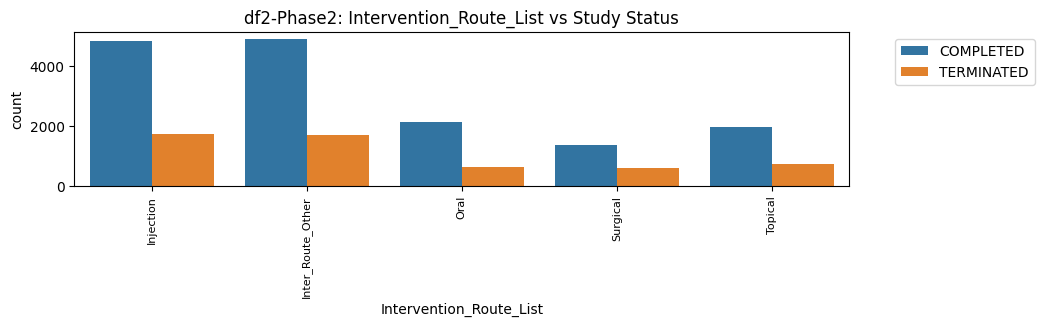

In [ ]:
Intervention_Route_List = log_fun("Intervention_Route_List", dfi, i, 'list', False, 90, 'Inter_Route_Other')

### Intervention_Route_Counts

df2-Phase 2:
Intervention_Route_Counts vs Study Status


count    16982.000000
mean         1.215228
std          0.472327
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          4.000000
Name: Intervention_Route_Counts, dtype: float64


count    1.698200e+04
mean     9.707097e-17
std      1.000029e+00
min     -4.556888e-01
25%     -4.556888e-01
50%     -4.556888e-01
75%     -4.556888e-01
max      5.896027e+00
Name: Intervention_Route_Counts, dtype: float64
                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                16982
Model:                          Logit   Df Residuals:                    16980
Method:                           MLE   Df Model:                            1
Date:                Sat, 04 Oct 2025   Pseudo R-squ.:                0.001390
Time:                        01:10:08   Log-Likelihood:                -9637.5
converged:         

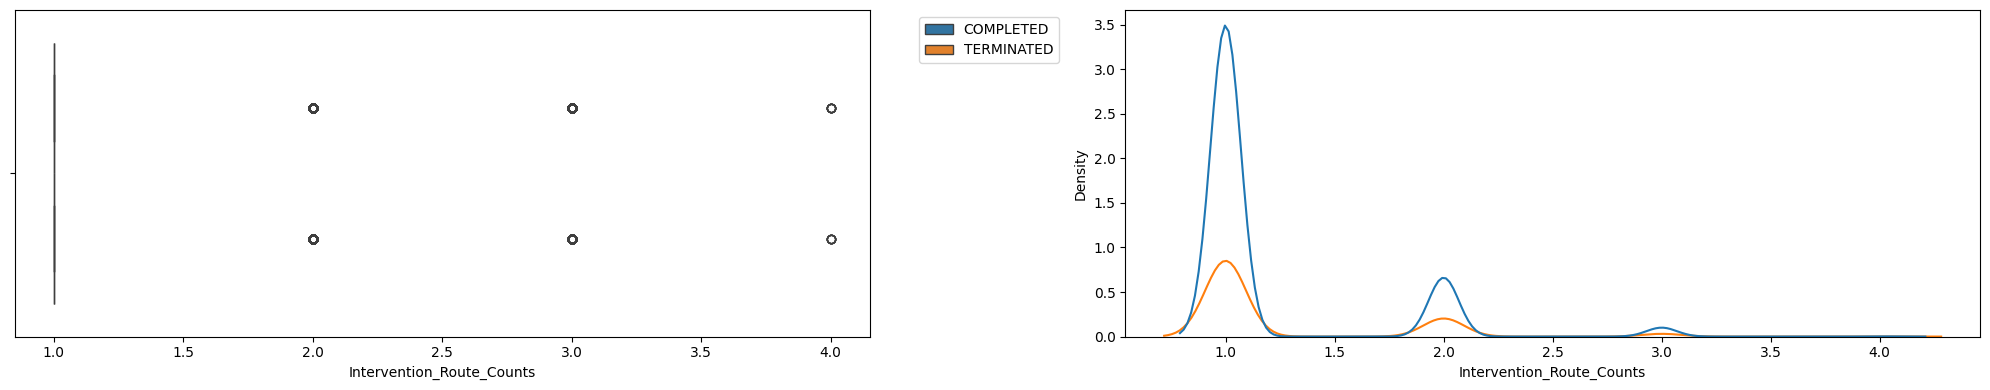

In [ ]:
Intervention_Route_Counts = log_fun_cont("Intervention_Route_Counts", dfi, i)

### Intervention_Route_Categ

df2-Phase 2:
Intervention_Route_Categ vs Study Status

p-value: 7.183556144351242e-08 < 0.05

------------------------------------------------------------------------------------------------------------

df2-Phase 2:
Intervention_Route_Categ vs Study Status (Termination)



Study_Status_Bin,COMPLETED,TERMINATED
Intervention_Route_Categ,,
1,10375,3399
2–4,2268,940


                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                16982
Model:                          Logit   Df Residuals:                    16980
Method:                           MLE   Df Model:                            1
Date:                Sat, 04 Oct 2025   Pseudo R-squ.:                0.001482
Time:                        01:10:08   Log-Likelihood:                -9636.6
converged:                       True   LL-Null:                       -9650.9
Covariance Type:            nonrobust   LLR p-value:                 8.909e-08
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                       -1.1159      0.020    -56.464      0.000      -1.155      -1.077
Intervention_Route_Categ     0.2351      0.044      5.401      0.000       0.150       0.

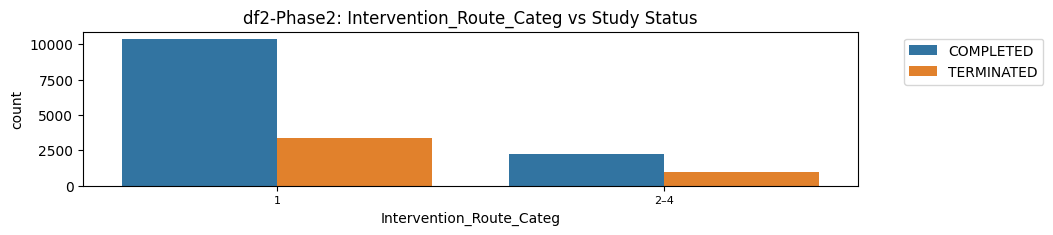

In [ ]:
chi2_fun('Intervention_Route_Categ', dfi, i)
#### Log_Fun
Intervention_Route_Categ = log_fun('Intervention_Route_Categ', dfi, i, 'bin', True, 0)

#### Format
- As continues, it has too many discrite values at 1 and a small sample at 2. No need for analysis. 
- That is why _Log was not checks too.

In [ ]:
Intervention_Route_Counts_aic = fun_compare(i, Intervention_Route_Counts = Intervention_Route_Counts[0], 
                                             Intervention_Route_Categ = Intervention_Route_Categ[0])
Intervention_Route_Counts_aic

,Intervention_Route_Counts,Intervention_Route_Categ,AIC_min
df2,,,
Intervention_Route_Counts,[19279.0],[19277.0],Intervention_Route_Categ


In [ ]:
dfi = dfi.drop(columns = ['Intervention_Route_Counts', 'Intervention_Route_Categ'], axis = 1)

## Locations

### City_Counts

df2-Phase 2:
City_Counts vs Study Status


count    16982.000000
mean        10.011895
std         23.268543
min          0.000000
25%          1.000000
50%          1.000000
75%          9.000000
max        643.000000
Name: City_Counts, dtype: float64


count    1.698200e+04
mean    -9.623415e-18
std      1.000029e+00
min     -4.302886e-01
25%     -3.873109e-01
50%     -3.873109e-01
75%     -4.348896e-02
max      2.720440e+01
Name: City_Counts, dtype: float64
                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                16982
Model:                          Logit   Df Residuals:                    16980
Method:                           MLE   Df Model:                            1
Date:                Sat, 04 Oct 2025   Pseudo R-squ.:                0.002456
Time:                        01:10:09   Log-Likelihood:                -9627.2
converged:                       True   LL-Null:             

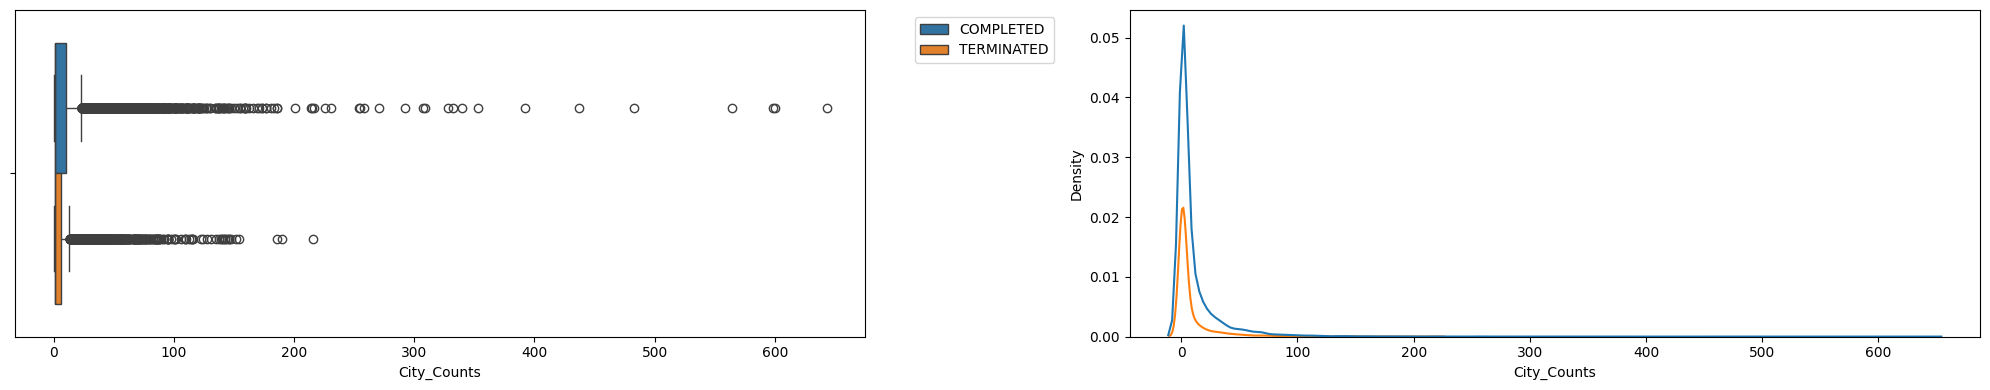

In [ ]:
City_Counts = log_fun_cont("City_Counts", dfi, i)

### City_Counts_Log

df2-Phase 2:
City_Counts_Log vs Study Status


count    16982.000000
mean         1.508983
std          1.175049
min          0.000000
25%          0.693147
50%          0.693147
75%          2.302585
max          6.467699
Name: City_Counts_Log, dtype: float64


count    1.698200e+04
mean     2.365059e-16
std      1.000029e+00
min     -1.284225e+00
25%     -6.943195e-01
50%     -6.943195e-01
75%      6.753977e-01
max      4.220131e+00
Name: City_Counts_Log, dtype: float64
                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                16982
Model:                          Logit   Df Residuals:                    16980
Method:                           MLE   Df Model:                            1
Date:                Sat, 04 Oct 2025   Pseudo R-squ.:                0.007424
Time:                        01:10:09   Log-Likelihood:                -9579.3
converged:                       True   LL-Null: 

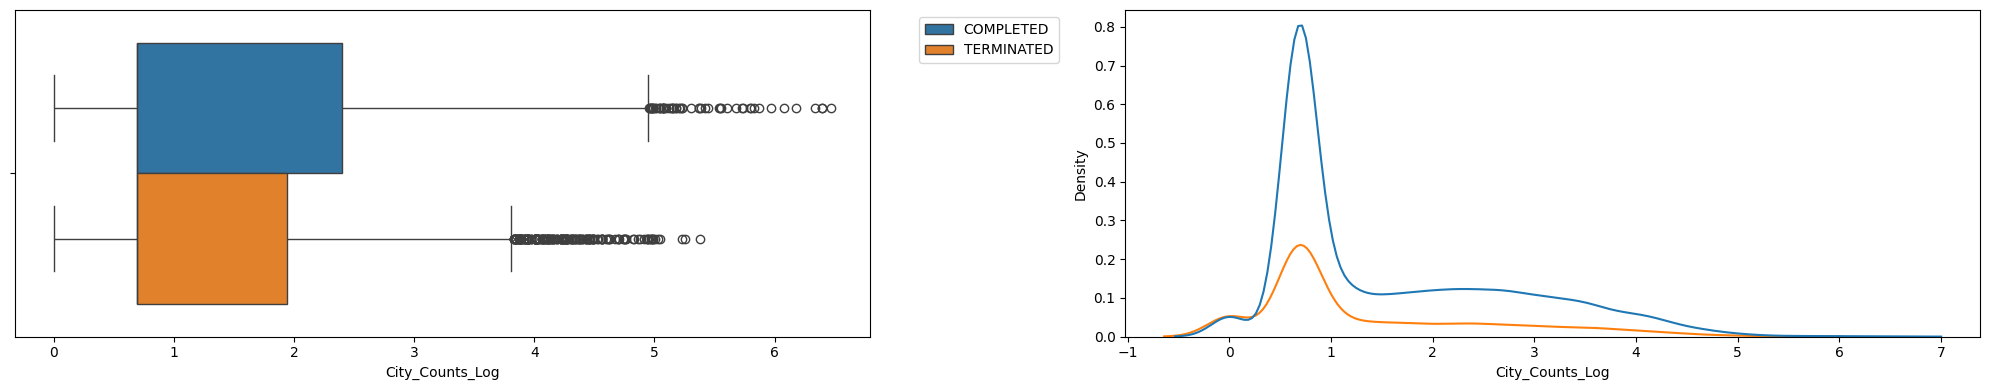

In [ ]:
City_Counts_Log = log_fun_cont("City_Counts_Log", dfi, i)

### City_Categ

df2-Phase 2:
City_Categ vs Study Status

p-value: 6.741491674620746e-22 < 0.05

------------------------------------------------------------------------------------------------------------

df2-Phase 2:
City_Categ vs Study Status (Termination)



Study_Status_Bin,COMPLETED,TERMINATED
City_Categ,,
0–1,6454,2582
2–667,6189,1757


                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                16982
Model:                          Logit   Df Residuals:                    16980
Method:                           MLE   Df Model:                            1
Date:                Sat, 04 Oct 2025   Pseudo R-squ.:                0.004837
Time:                        01:10:10   Log-Likelihood:                -9604.2
converged:                       True   LL-Null:                       -9650.9
Covariance Type:            nonrobust   LLR p-value:                 4.347e-22
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.9161      0.023    -39.343      0.000      -0.962      -0.870
City_Categ    -0.3430      0.036     -9.615      0.000      -0.413      -0.273


df2-Phase2: City_Categ p-values:
[const         0.

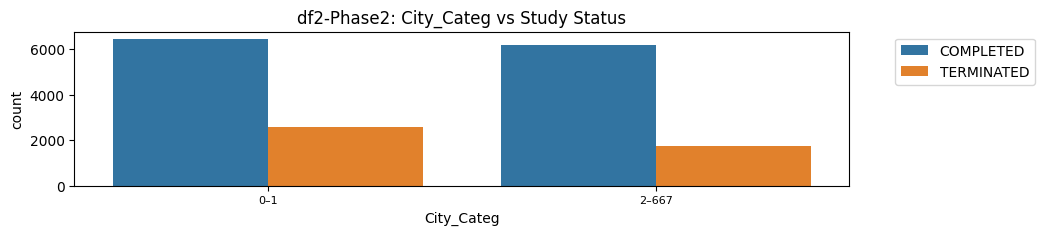

In [ ]:
chi2_fun('City_Categ', dfi, i)
#### log_fun
City_Categ = log_fun('City_Categ', dfi, i, 'bin', False, 0)

#### Format
- Distribution is almost all at 1.
- Howver, the question answered from this feature is if multi vs single facilities.
- Categ is goind to be used. 


In [ ]:
City_Counts_aic = fun_compare(i, City_Counts = City_Counts[0], 
                              City_Counts_Log = City_Counts_Log[0],
                              City_Categ = City_Categ[0]
                              )
City_Counts_aic

,City_Counts,City_Counts_Log,City_Categ,AIC_min
df2,,,,
City_Counts,[19258.0],[19163.0],[19212.0],City_Counts_Log


In [ ]:
dfi = dfi.drop(columns = ['City_Counts', 'City_Categ'], axis = 1)

### Country_Counts


df2-Phase 2:
Country_Counts vs Study Status


count    16982.000000
mean         1.947415
std          2.947353
min          0.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         37.000000
Name: Country_Counts, dtype: float64


count    1.698200e+04
mean    -7.656891e-17
std      1.000029e+00
min     -6.607530e-01
25%     -3.214555e-01
50%     -3.214555e-01
75%     -3.214555e-01
max      1.189326e+01
Name: Country_Counts, dtype: float64
                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                16982
Model:                          Logit   Df Residuals:                    16980
Method:                           MLE   Df Model:                            1
Date:                Sat, 04 Oct 2025   Pseudo R-squ.:               0.0002251
Time:                        01:10:10   Log-Likelihood:                -9648.8
converged:                       True   LL-Null:    

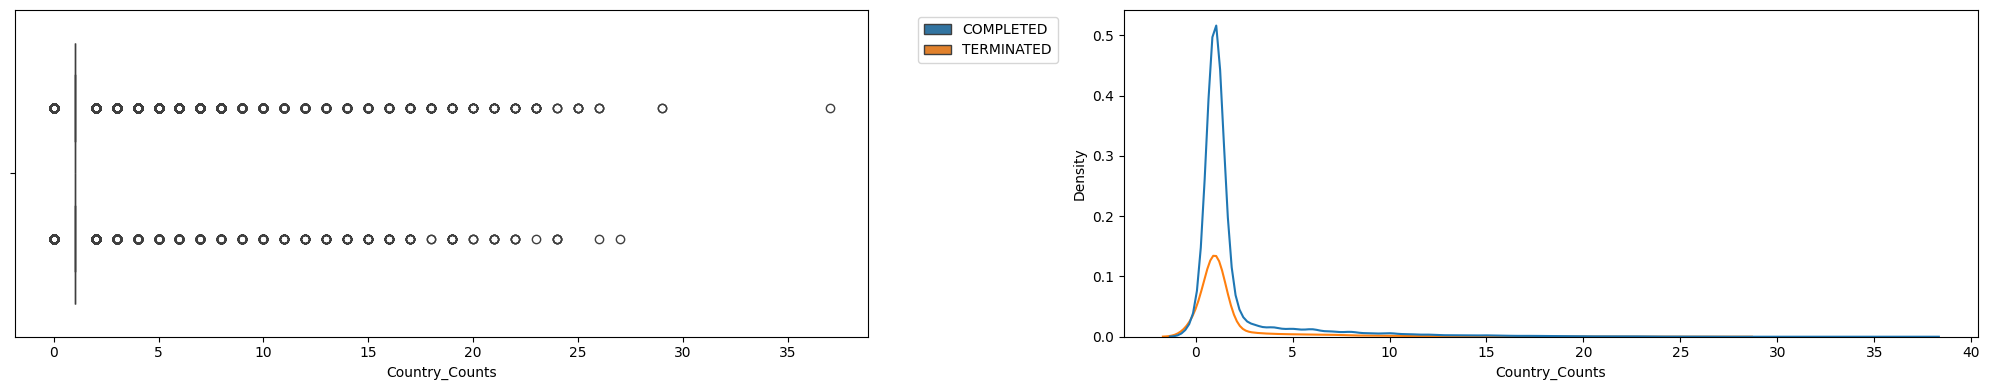

In [ ]:
Country_Counts = log_fun_cont("Country_Counts", dfi, i)

### Country_Counts_Log

df2-Phase 2:
Country_Counts_Log vs Study Status


count    16982.000000
mean         0.869793
std          0.538385
min          0.000000
25%          0.693147
50%          0.693147
75%          0.693147
max          3.637586
Name: Country_Counts_Log, dtype: float64


count    1.698200e+04
mean    -1.164747e-16
std      1.000029e+00
min     -1.615608e+00
25%     -3.281126e-01
50%     -3.281126e-01
75%     -3.281126e-01
max      5.141073e+00
Name: Country_Counts_Log, dtype: float64
                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                16982
Model:                          Logit   Df Residuals:                    16980
Method:                           MLE   Df Model:                            1
Date:                Sat, 04 Oct 2025   Pseudo R-squ.:                0.002687
Time:                        01:10:11   Log-Likelihood:                -9625.0
converged:                       True   

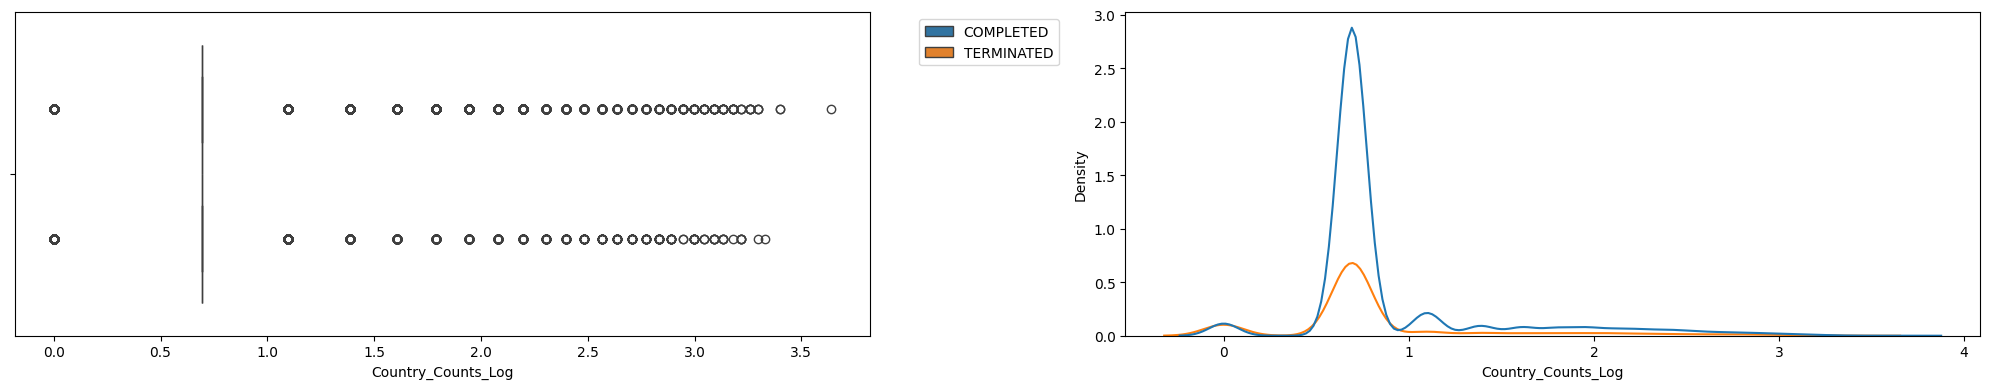

In [ ]:
Country_Counts_Log = log_fun_cont("Country_Counts_Log", dfi, i)

### Country_Categ

df2-Phase 2:
Country_Categ vs Study Status

p-value: 0.0007677455897479093 < 0.05

------------------------------------------------------------------------------------------------------------

df2-Phase 2:
Country_Categ vs Study Status (Termination)



Study_Status_Bin,COMPLETED,TERMINATED
Country_Categ,,
0–1,10107,3571
2–37,2536,768


                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                16982
Model:                          Logit   Df Residuals:                    16980
Method:                           MLE   Df Model:                            1
Date:                Sat, 04 Oct 2025   Pseudo R-squ.:               0.0006036
Time:                        01:10:11   Log-Likelihood:                -9645.1
converged:                       True   LL-Null:                       -9650.9
Covariance Type:            nonrobust   LLR p-value:                 0.0006421
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -1.0404      0.019    -53.443      0.000      -1.079      -1.002
Country_Categ    -0.1542      0.046     -3.384      0.001      -0.243      -0.065


df2-Phase2: Country_Categ p-values:
[c

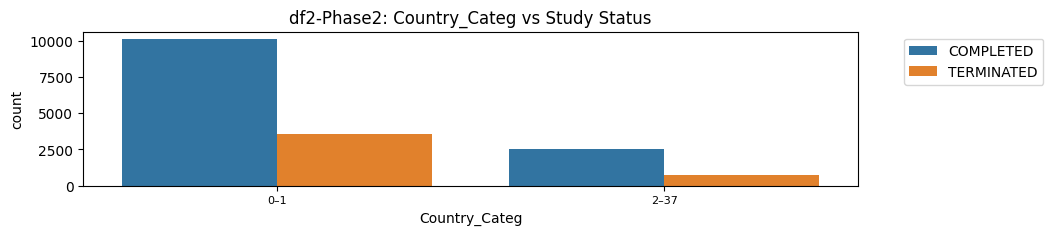

In [ ]:
chi2_fun('Country_Categ', dfi, i)
#### log_fun
Country_Categ = log_fun('Country_Categ', dfi, i, 'bin', True, 0)

#### Format
- Sparse Risk with categ
- However, the question to answer is global/non-global trials.


In [ ]:
Country_Counts_aic = fun_compare(i, Country_Counts = Country_Counts[0], 
                                 Country_Counts_Log = Country_Counts_Log[0],
                                 Country_Categ = Country_Categ[0])
Country_Counts_aic

,Country_Counts,Country_Counts_Log,Country_Categ,AIC_min
df2,,,,
Country_Counts,[19302.0],[19254.0],[19294.0],Country_Counts_Log


In [ ]:
dfi = dfi.drop(columns = ['Country_Counts', 'Country_Categ'], axis = 1)

### Continents_List 

df2-Phase 2:
Continents_List vs Study Status (Termination)



Study_Status_Bin,COMPLETED,TERMINATED
Continents_List,,
Asia,2604,594
Cont_Other,2067,868
Europe,4094,1189
North America,6989,2775


                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                16982
Model:                          Logit   Df Residuals:                    16978
Method:                           MLE   Df Model:                            3
Date:                Sat, 04 Oct 2025   Pseudo R-squ.:                0.009252
Time:                        01:10:12   Log-Likelihood:                -9561.6
converged:                       True   LL-Null:                       -9650.9
Covariance Type:            nonrobust   LLR p-value:                 1.785e-38
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -1.0848      0.039    -28.032      0.000      -1.161      -1.009
Asia             -0.4137      0.052     -8.021      0.000      -0.515      -0.313
Europe           -0.1627      0.042     

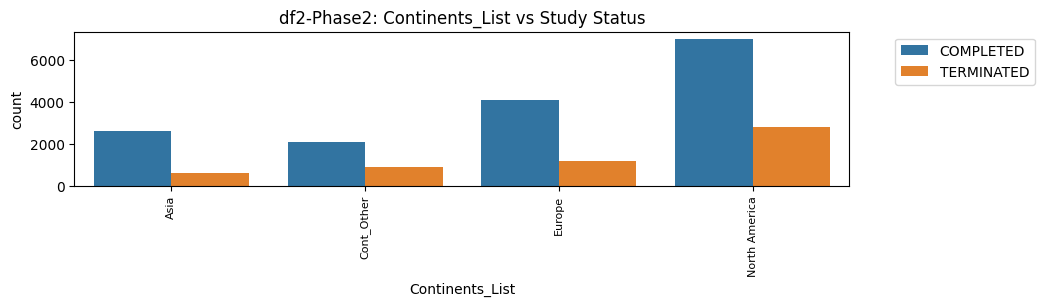

In [ ]:
Continents_List = log_fun("Continents_List", dfi, i, 'list', False, 90, 'Cont_Other')

### Continent_Counts

df2-Phase 2:
Continent_Counts vs Study Status


count    16982.000000
mean         1.152043
std          0.809134
min          0.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          6.000000
Name: Continent_Counts, dtype: float64


count    1.698200e+04
mean     7.290783e-17
std      1.000029e+00
min     -1.423840e+00
25%     -1.879143e-01
50%     -1.879143e-01
75%     -1.879143e-01
max      5.991714e+00
Name: Continent_Counts, dtype: float64
                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                16982
Model:                          Logit   Df Residuals:                    16980
Method:                           MLE   Df Model:                            1
Date:                Sat, 04 Oct 2025   Pseudo R-squ.:               0.0003458
Time:                        01:10:12   Log-Likelihood:                -9647.6
converged:                       True   LL-Nul

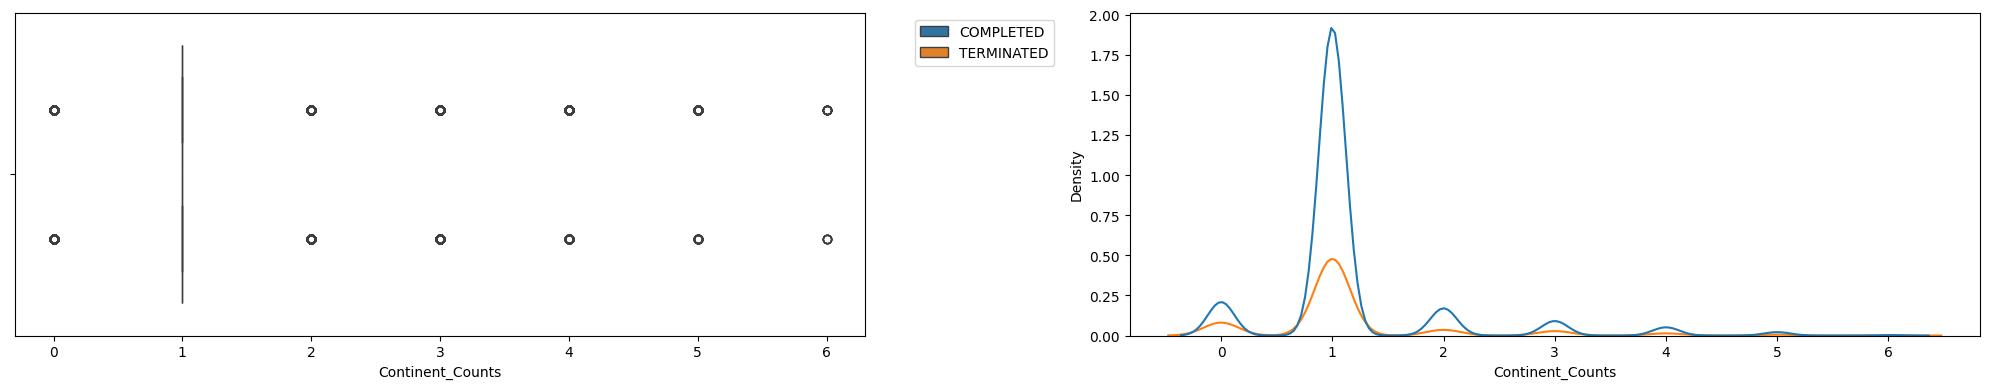

In [ ]:
Continent_Counts = log_fun_cont("Continent_Counts", dfi, i)

### Continent_Counts_Log

df2-Phase 2:
Continent_Counts_Log vs Study Status


count    16982.000000
mean         0.710940
std          0.324034
min          0.000000
25%          0.693147
50%          0.693147
75%          0.693147
max          1.945910
Name: Continent_Counts_Log, dtype: float64


count    1.698200e+04
mean    -2.307527e-16
std      1.000029e+00
min     -2.194093e+00
25%     -5.491090e-02
50%     -5.491090e-02
75%     -5.491090e-02
max      3.811350e+00
Name: Continent_Counts_Log, dtype: float64
                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                16982
Model:                          Logit   Df Residuals:                    16980
Method:                           MLE   Df Model:                            1
Date:                Sat, 04 Oct 2025   Pseudo R-squ.:                0.001251
Time:                        01:10:13   Log-Likelihood:                -9638.9
converged:                       T

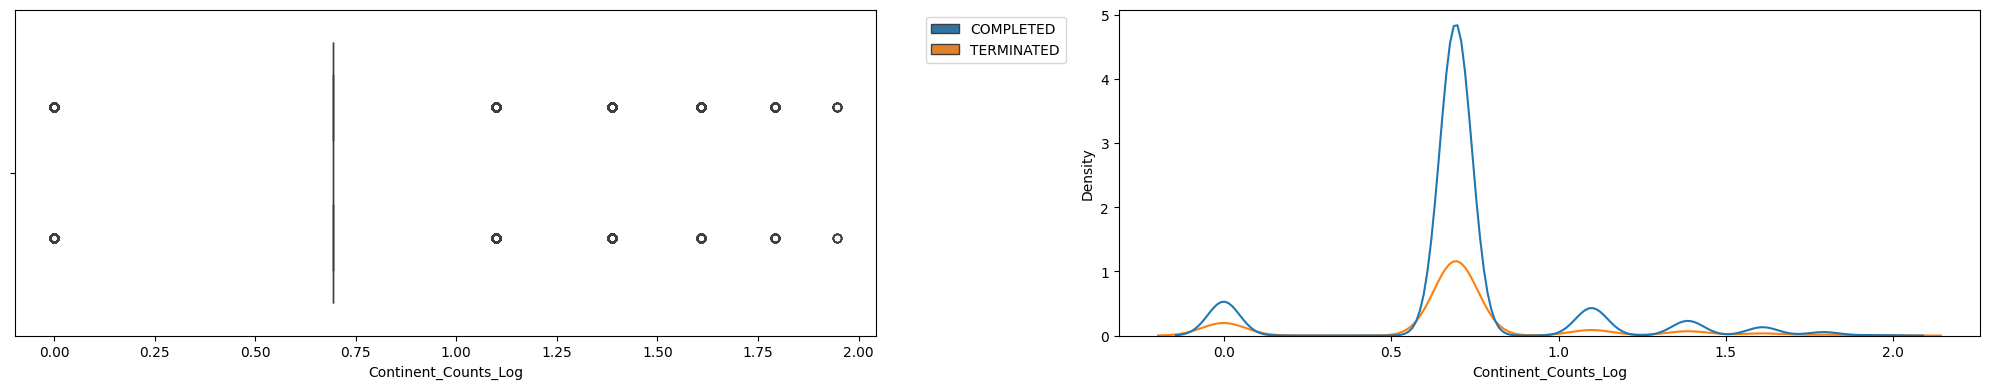

In [ ]:
Continent_Counts_Log = log_fun_cont("Continent_Counts_Log", dfi, i)

### Continent_Categ

df2-Phase 2:
Continent_Categ vs Study Status

p-value: 0.35081286226665653 > 0.05 - No significant difference

------------------------------------------------------------------------------------------------------------

df2-Phase 2:
Continent_Categ vs Study Status (Termination)



Study_Status_Bin,COMPLETED,TERMINATED
Continent_Categ,,
0–1,10918,3772
2–6,1725,567


                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                16982
Model:                          Logit   Df Residuals:                    16980
Method:                           MLE   Df Model:                            1
Date:                Sat, 04 Oct 2025   Pseudo R-squ.:               4.791e-05
Time:                        01:10:13   Log-Likelihood:                -9650.5
converged:                       True   LL-Null:                       -9650.9
Covariance Type:            nonrobust   LLR p-value:                    0.3362
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -1.0628      0.019    -56.275      0.000      -1.100      -1.026
Continent_Categ    -0.0495      0.052     -0.953      0.340      -0.151       0.052


df2-Phase2: Continent_Categ p-

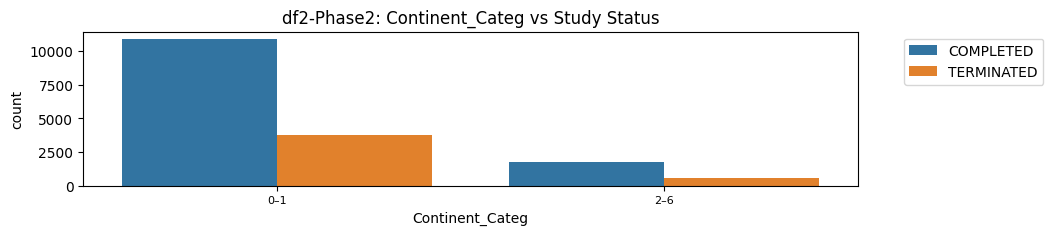

In [ ]:
chi2_fun('Continent_Categ', dfi, i)
#### log_fun
Continent_Categ = log_fun('Continent_Categ', dfi, i, 'bin', True, 0)

#### Format
- Sparsity Risk with categ.
- However, question answered is global/global
- Will all Continent counts be dropped, as the global/non-global is answered through countries as well. 
- Also, Continenets are have more sparse risk than Countries.

In [ ]:
Continent_Counts_aic = fun_compare(i, Continent_Counts = Continent_Counts[0], 
                                   Continent_Counts_Log = Continent_Counts_Log[0],
                                Continent_Categ = Continent_Categ[0]

                                   )
Continent_Counts_aic

,Continent_Counts,Continent_Counts_Log,Continent_Categ,AIC_min
df2,,,,
Continent_Counts,[19299.0],[19282.0],[19305.0],Continent_Counts_Log


In [ ]:
dfi = dfi.drop(columns = ['Continent_Counts',  'Continent_Categ'])

## Datetimes

### Start_Date_Year_Counts

df2-Phase 2:
Start_Date_Year_Counts vs Study Status


count        16982.0
mean     2016.200742
std         3.475123
min           2011.0
25%           2013.0
50%           2016.0
75%           2019.0
max           2024.0
Name: Start_Date_Year_Counts, dtype: Float64


count    1.698200e+04
mean     6.101873e-15
std      1.000029e+00
min     -1.496608e+00
25%     -9.210714e-01
50%     -5.776713e-02
75%      8.055372e-01
max      2.244378e+00
Name: Start_Date_Year_Counts, dtype: float64
                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                16982
Model:                          Logit   Df Residuals:                    16980
Method:                           MLE   Df Model:                            1
Date:                Sat, 04 Oct 2025   Pseudo R-squ.:                 0.01027
Time:                        01:10:14   Log-Likelihood:                -9551.8
converged:                       Tru

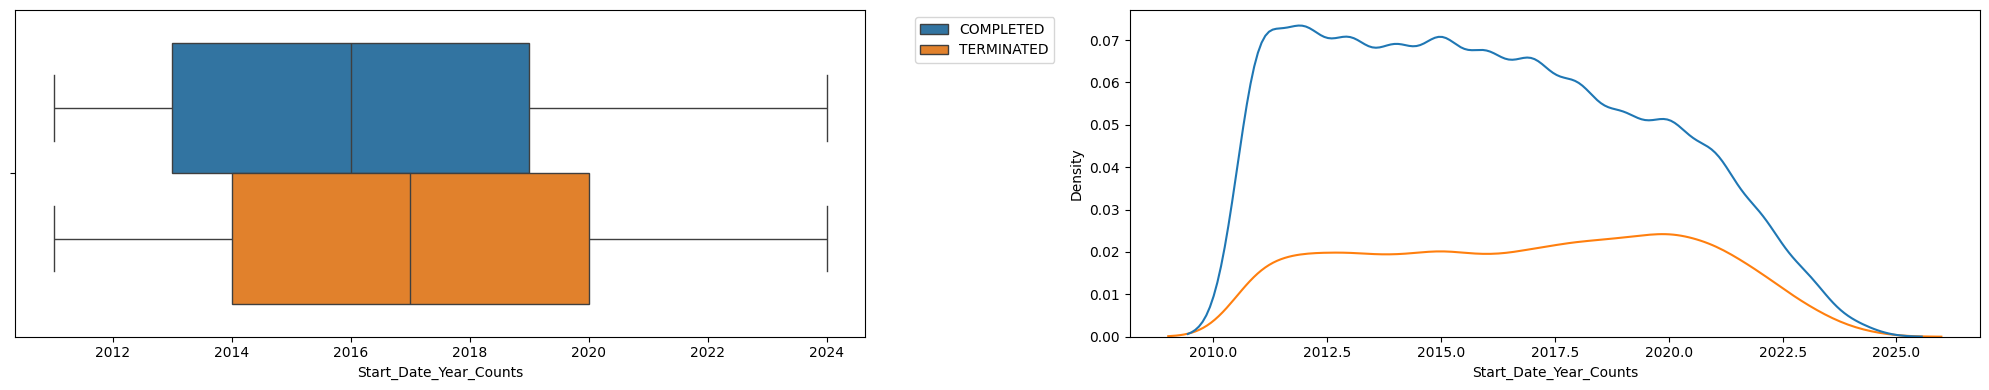

In [ ]:
Start_Date_Year_Counts = log_fun_cont("Start_Date_Year_Counts", dfi, i)

### Start_Date_Year_Categ
- Categorization is covid dates oriented

df2-Phase 2:
Start_Date_Year_Categ vs Study Status

p-value: 1.035126400793695e-43 < 0.05

------------------------------------------------------------------------------------------------------------

df2-Phase 2:
Start_Date_Year_Categ vs Study Status (Termination)



Study_Status_Bin,COMPLETED,TERMINATED
Start_Date_Year_Categ,,
2011-2018,9333,2722
2019-2024,3310,1617


                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                16982
Model:                          Logit   Df Residuals:                    16980
Method:                           MLE   Df Model:                            1
Date:                Sat, 04 Oct 2025   Pseudo R-squ.:                0.009689
Time:                        01:10:14   Log-Likelihood:                -9557.4
converged:                       True   LL-Null:                       -9650.9
Covariance Type:            nonrobust   LLR p-value:                 1.428e-42
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    -1.2322      0.022    -56.565      0.000      -1.275      -1.189
Start_Date_Year_Categ     0.5158      0.037     13.810      0.000       0.443       0.589


df2-Ph

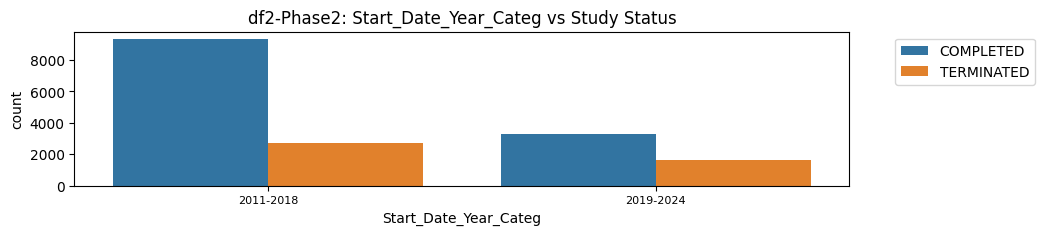

In [ ]:
chi2_fun("Start_Date_Year_Categ", dfi, i)
#### log_fun
Start_Date_Year_Categ = log_fun("Start_Date_Year_Categ", dfi, i, 'bin', True, 0)

### Completion_Date_Year 
- will not run AIC --> Date - Year itself is not a feature affecting the outcome.



df2-Phase 2:
Completion_Date_Year_Counts vs Study Status


count       16982.0
mean     2018.79596
std        3.513424
min          2011.0
25%          2016.0
50%          2019.0
75%          2022.0
max          2024.0
Name: Completion_Date_Year_Counts, dtype: Float64


count    1.698200e+04
mean     2.471858e-14
std      1.000029e+00
min     -2.218972e+00
25%     -7.958170e-01
50%      5.807599e-02
75%      9.119690e-01
max      1.481231e+00
Name: Completion_Date_Year_Counts, dtype: float64
                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                16982
Model:                          Logit   Df Residuals:                    16980
Method:                           MLE   Df Model:                            1
Date:                Sat, 04 Oct 2025   Pseudo R-squ.:                0.001797
Time:                        01:10:15   Log-Likelihood:                -9633.6
converged:                   

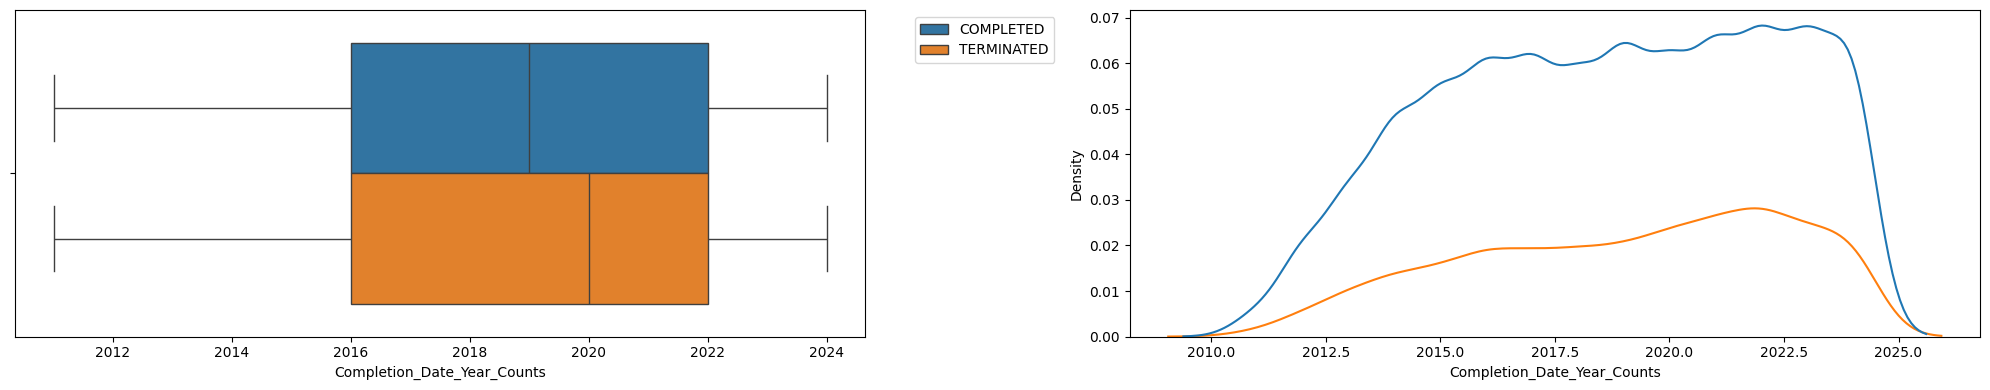

In [ ]:
Completion_Date_Year_Counts = log_fun_cont("Completion_Date_Year_Counts", dfi, i)
# Plot is higher to completion as year pass --> Logic as trials of dataset are 2011-2024. 
# At 2011 that all started no trial was finished.

### Completion_Date_Year_Categ
- Categorization is covid dates oriented

df2-Phase 2:
Completion_Date_Year_Categ vs Study Status

p-value: 1.8524998331741587e-08 < 0.05

------------------------------------------------------------------------------------------------------------

df2-Phase 2:
Completion_Date_Year_Categ vs Study Status (Termination)



Study_Status_Bin,COMPLETED,TERMINATED
Completion_Date_Year_Categ,,
2011-2018,5896,1809
2019-2024,6747,2530


                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                16982
Model:                          Logit   Df Residuals:                    16980
Method:                           MLE   Df Model:                            1
Date:                Sat, 04 Oct 2025   Pseudo R-squ.:                0.001656
Time:                        01:10:15   Log-Likelihood:                -9634.9
converged:                       True   LL-Null:                       -9650.9
Covariance Type:            nonrobust   LLR p-value:                 1.572e-08
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                         -1.1815      0.027    -43.959      0.000      -1.234      -1.129
Completion_Date_Year_Categ     0.2006      0.036      5.639      0.000       0.131 

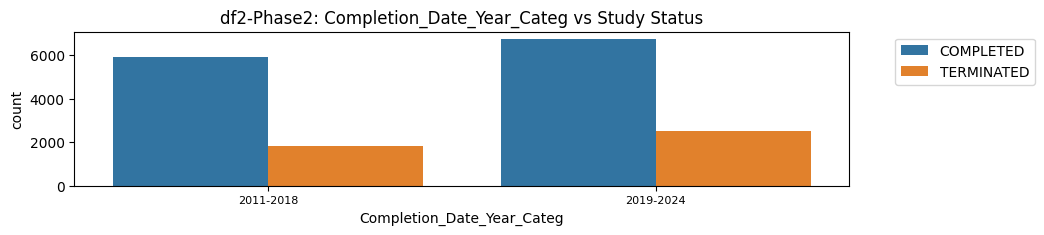

In [ ]:
chi2_fun("Completion_Date_Year_Categ", dfi, i)
### log_fun
Completion_Date_Year_Categ = log_fun("Completion_Date_Year_Categ", dfi, i, 'bin', True, 0)

#### Drop

In [ ]:
dfi = dfi.drop(columns = ['Start_Date_Year_Counts', 'Start_Date_Year_Categ', 
                         'Completion_Date_Year_Counts', 'Completion_Date_Year_Categ'], axis = 1)

### Completion_Gap_Counts

- Notice Termination main Distribution median = Around 20 participants --> cutpoint
- A trials holding too long may risk patients dropping out.

df2-Phase 2:
Completion_Gap_Counts vs Study Status


count      16982.0
mean      31.50371
std      24.269048
min            0.0
25%           13.0
50%           25.0
75%           44.0
max          163.0
Name: Completion_Gap_Counts, dtype: Float64


count    1.698200e+04
mean    -3.012547e-17
std      1.000029e+00
min     -1.298141e+00
25%     -7.624631e-01
50%     -2.679916e-01
75%      5.149216e-01
max      5.418431e+00
Name: Completion_Gap_Counts, dtype: float64
                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                16982
Model:                          Logit   Df Residuals:                    16980
Method:                           MLE   Df Model:                            1
Date:                Sat, 04 Oct 2025   Pseudo R-squ.:                 0.01113
Time:                        01:10:16   Log-Likelihood:                -9543.6
converged:                       True   LL-Null:       

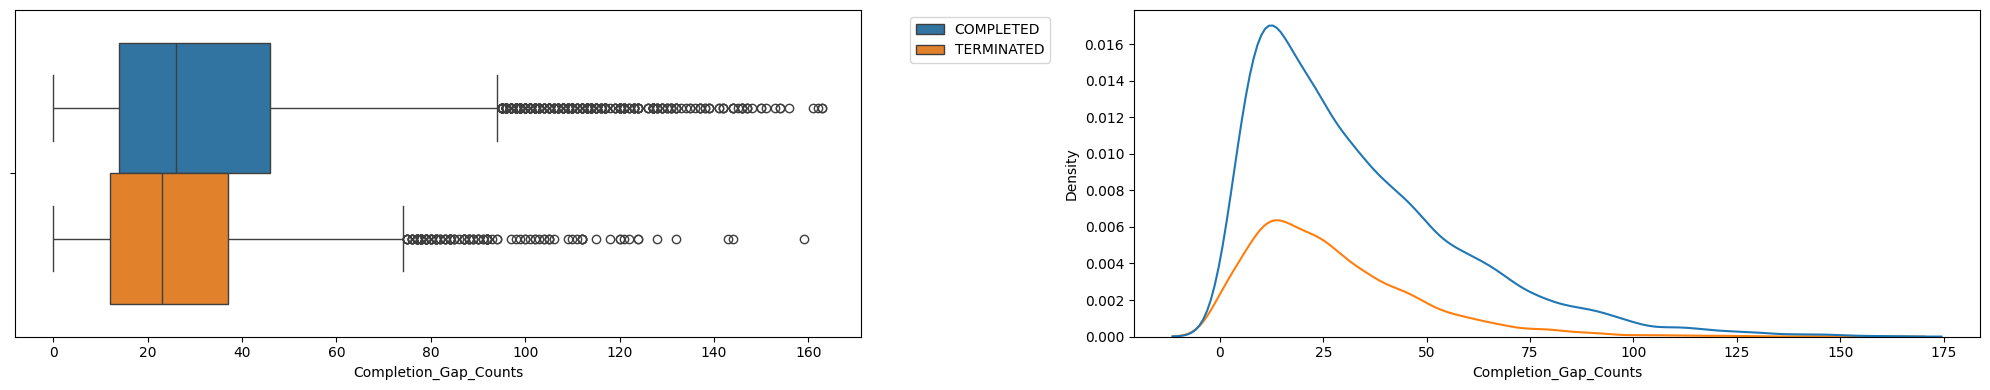

In [ ]:
Completion_Gap_Counts = log_fun_cont("Completion_Gap_Counts", dfi, i)

### Completion_Gap_Log

df2-Phase 2:
Completion_Gap_Log vs Study Status


count     16982.0
mean     3.176309
std      0.861225
min           0.0
25%      2.639057
50%      3.258097
75%      3.806662
max      5.099866
Name: Completion_Gap_Log, dtype: Float64


count    1.698200e+04
mean    -4.832628e-17
std      1.000029e+00
min     -3.688239e+00
25%     -6.238410e-01
50%      9.496970e-02
75%      7.319489e-01
max      2.233580e+00
Name: Completion_Gap_Log, dtype: float64
                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                16982
Model:                          Logit   Df Residuals:                    16980
Method:                           MLE   Df Model:                            1
Date:                Sat, 04 Oct 2025   Pseudo R-squ.:                 0.01043
Time:                        01:10:16   Log-Likelihood:                -9550.3
converged:                       True   LL-Null:                       -

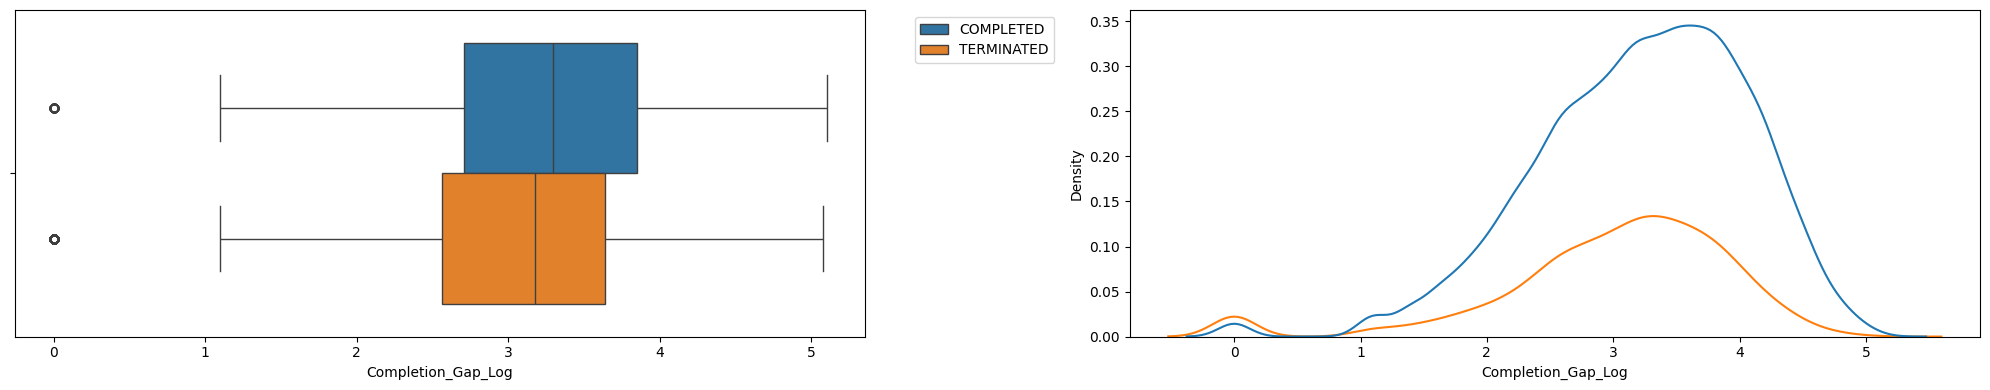

In [ ]:
Completion_Gap_Log = log_fun_cont("Completion_Gap_Log", dfi, i)

### Completion_Gap_Categ

df2-Phase 2:
Completion_Gap_Categ vs Study Status

p-value: 1.5957556059929258e-16 < 0.05

------------------------------------------------------------------------------------------------------------

df2-Phase 2:
Completion_Gap_Categ vs Study Status (Termination)



Study_Status_Bin,COMPLETED,TERMINATED
Completion_Gap_Categ,,
0–25,6167,2432
26–163,6476,1907


                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                16982
Model:                          Logit   Df Residuals:                    16980
Method:                           MLE   Df Model:                            1
Date:                Sat, 04 Oct 2025   Pseudo R-squ.:                0.003548
Time:                        01:10:17   Log-Likelihood:                -9616.7
converged:                       True   LL-Null:                       -9650.9
Covariance Type:            nonrobust   LLR p-value:                 1.279e-16
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   -0.9305      0.024    -38.861      0.000      -0.977      -0.884
Completion_Gap_Categ    -0.2921      0.035     -8.254      0.000      -0.361      -0.223


df2-Phase2

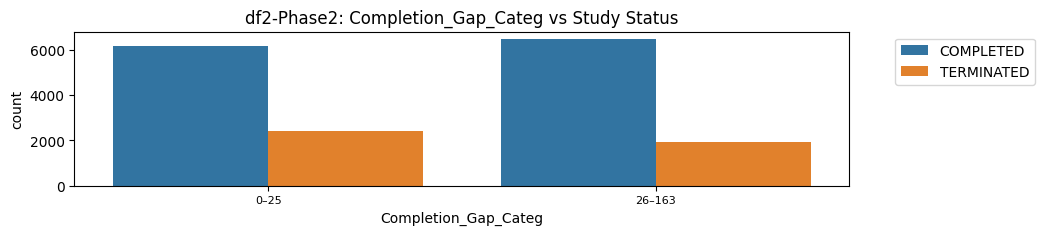

In [ ]:
chi2_fun('Completion_Gap_Categ', dfi, i)
#### log_fun
Completion_Gap_Categ = log_fun('Completion_Gap_Categ', dfi, i, 'bin', True, 0)

#### Drop
- Start date is the date first partcipants enrolled.
- Completion date is day last participant took intervention.
- Thus, it is not a predesigned characteristic and is not goind to be used as feature.

In [ ]:
dfi = dfi.drop(columns = ['Completion_Gap_Counts', 'Completion_Gap_Log', 'Completion_Gap_Categ'], axis=1)

## Enrollment

### Enrollment_Counts

df2-Phase 2:
Enrollment_Counts vs Study Status


count     16982.000000
mean        103.413202
std        1132.330094
min           0.000000
25%          16.000000
50%          43.000000
75%         103.000000
max      144539.000000
Name: Enrollment_Counts, dtype: float64


count    1.698200e+04
mean    -5.962333e-18
std      1.000029e+00
min     -9.133048e-02
25%     -7.719991e-02
50%     -5.335457e-02
75%     -3.649240e-04
max      1.275598e+02
Name: Enrollment_Counts, dtype: float64
                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                16982
Model:                          Logit   Df Residuals:                    16980
Method:                           MLE   Df Model:                            1
Date:                Sat, 04 Oct 2025   Pseudo R-squ.:                 0.09189
Time:                        01:10:17   Log-Likelihood:                -8764.1
converged:                       Tr

C:\Users\Eugenia\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
C:\Users\Eugenia\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))


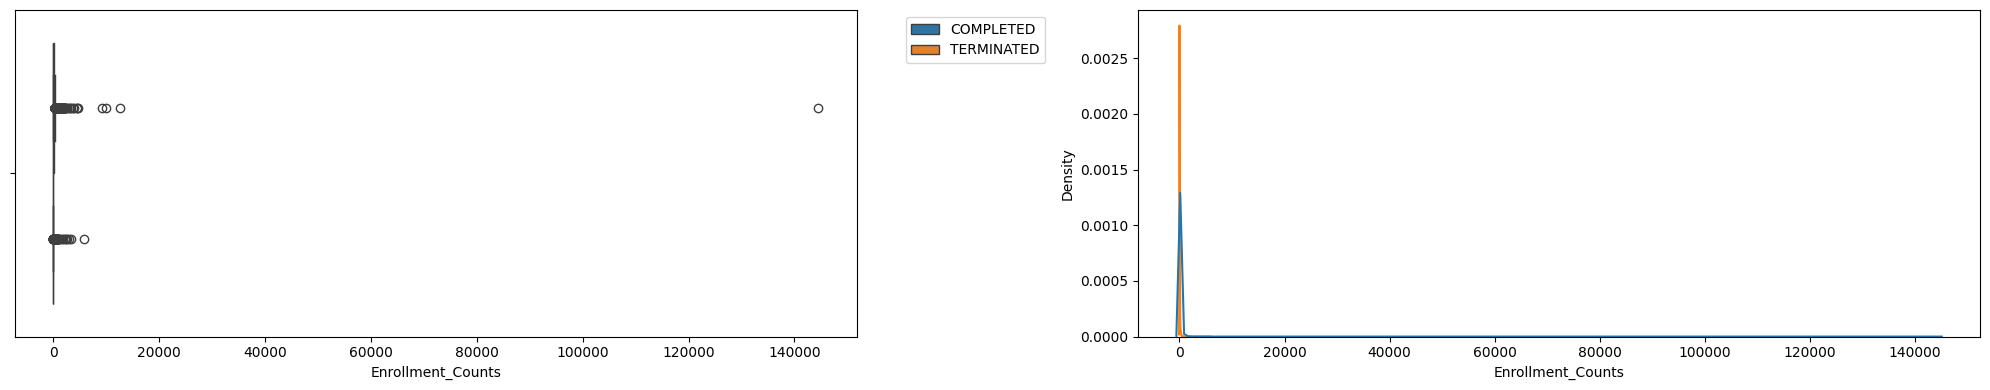

In [ ]:
Enrollment_Counts = log_fun_cont("Enrollment_Counts", dfi, i)

Text(0.5, 0.98, 'Enrollment_Counts Scatterplots by Phase')

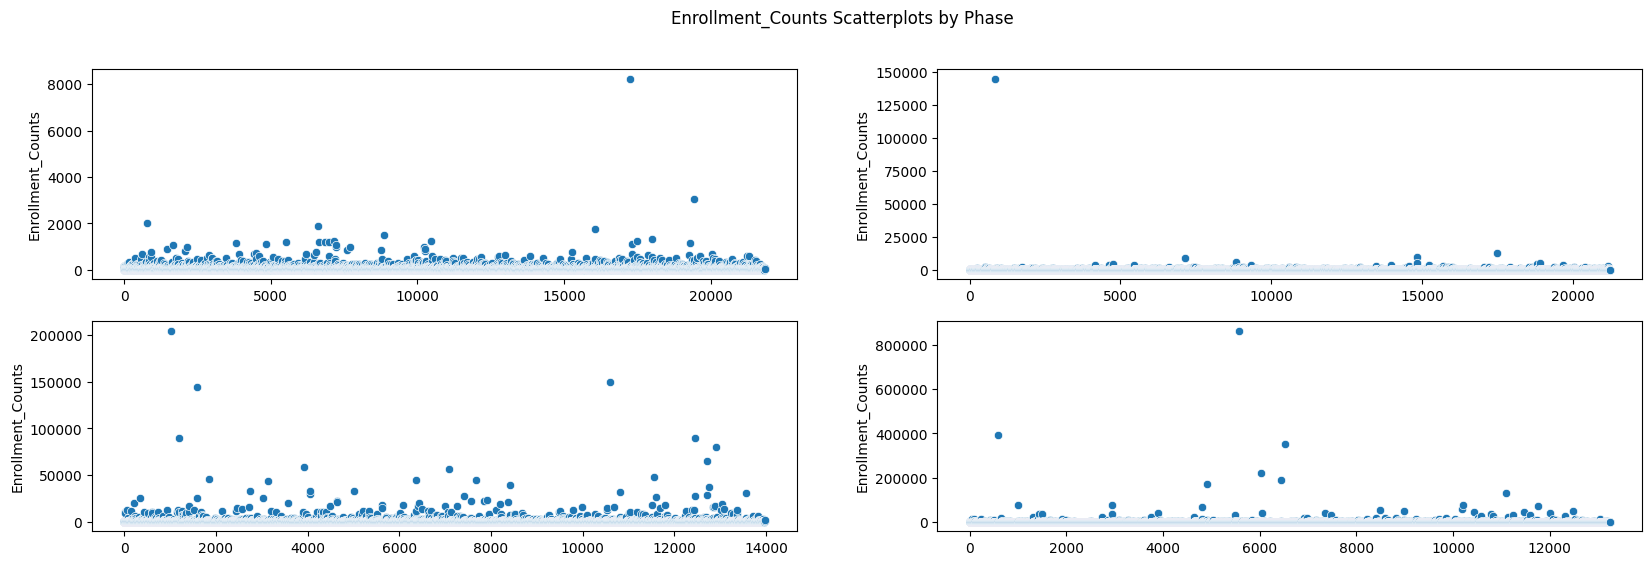

In [ ]:
plt.fig, ax = plt.subplots(figsize=(20, 6), nrows = 2, ncols = 2)

sns.scatterplot(df1['Enrollment_Counts'], ax=ax[0,0])
sns.scatterplot(df2['Enrollment_Counts'], ax=ax[0,1])
sns.scatterplot(df3['Enrollment_Counts'], ax=ax[1,0])
sns.scatterplot(df4['Enrollment_Counts'], ax=ax[1,1])

plt.fig.suptitle('Enrollment_Counts Scatterplots by Phase')

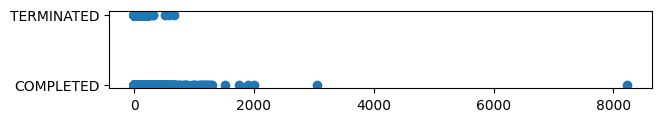

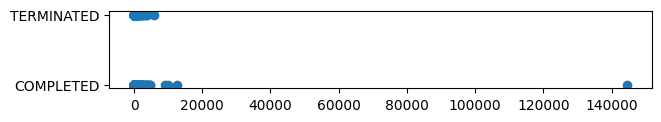

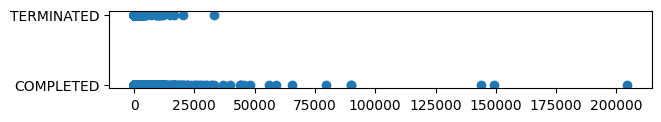

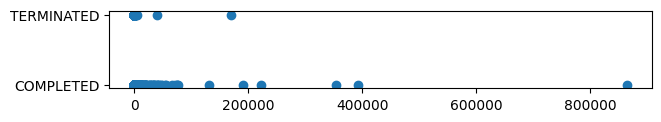

In [ ]:
plt.figure(figsize=(7,1))
plt.scatter(df1['Enrollment_Counts'], df1['Study_Status_Bin'])
plt.figure(figsize=(7,1))
plt.scatter(df2['Enrollment_Counts'], df2['Study_Status_Bin'])
plt.figure(figsize=(7,1))
plt.scatter(df3['Enrollment_Counts'], df3['Study_Status_Bin'])
plt.figure(figsize=(7,1))
plt.scatter(df4['Enrollment_Counts'], df4['Study_Status_Bin'])

### Enrollment_Counts_Log

df2-Phase 2:
Enrollment_Counts_Log vs Study Status


count    16982.000000
mean         3.607131
std          1.553940
min          0.000000
25%          2.833213
50%          3.784190
75%          4.644391
max         11.881312
Name: Enrollment_Counts_Log, dtype: float64


count    1.698200e+04
mean    -2.397485e-16
std      1.000029e+00
min     -2.321349e+00
25%     -4.980504e-01
50%      1.139449e-01
75%      6.675225e-01
max      5.324801e+00
Name: Enrollment_Counts_Log, dtype: float64
                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                16982
Model:                          Logit   Df Residuals:                    16980
Method:                           MLE   Df Model:                            1
Date:                Sat, 04 Oct 2025   Pseudo R-squ.:                  0.3158
Time:                        01:10:20   Log-Likelihood:                -6603.0
converged:                     

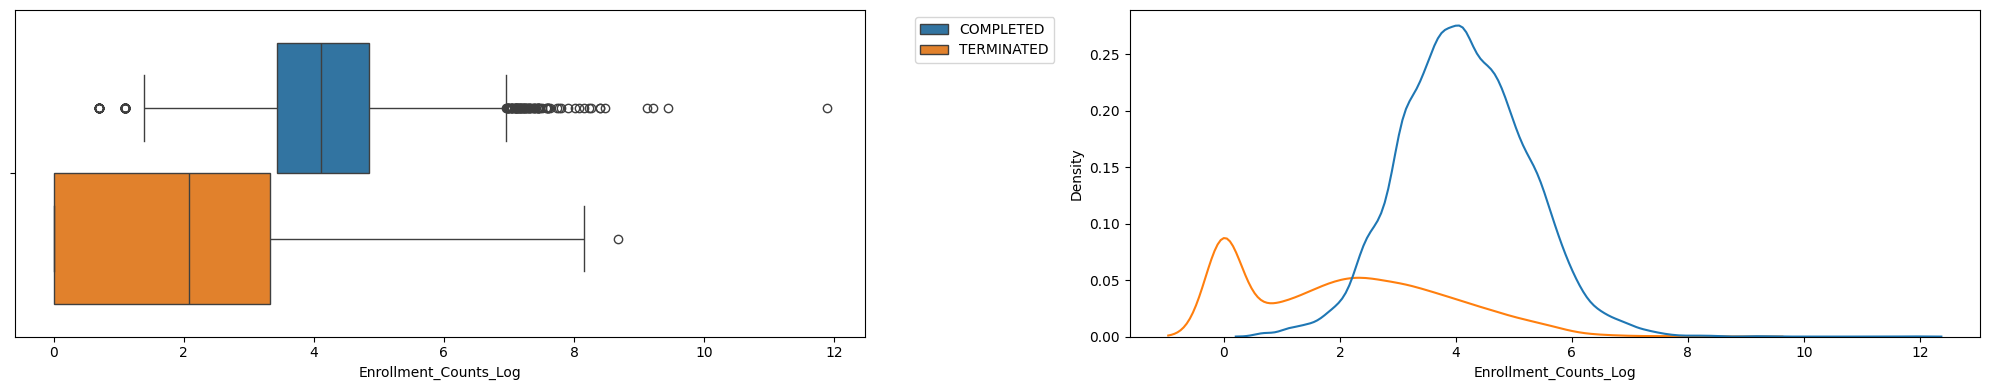

In [ ]:
Enrollment_Counts_Log = log_fun_cont("Enrollment_Counts_Log", dfi, i)

Text(0.5, 0.98, 'Enrollment_Counts_Log Scatterplots by Phase')

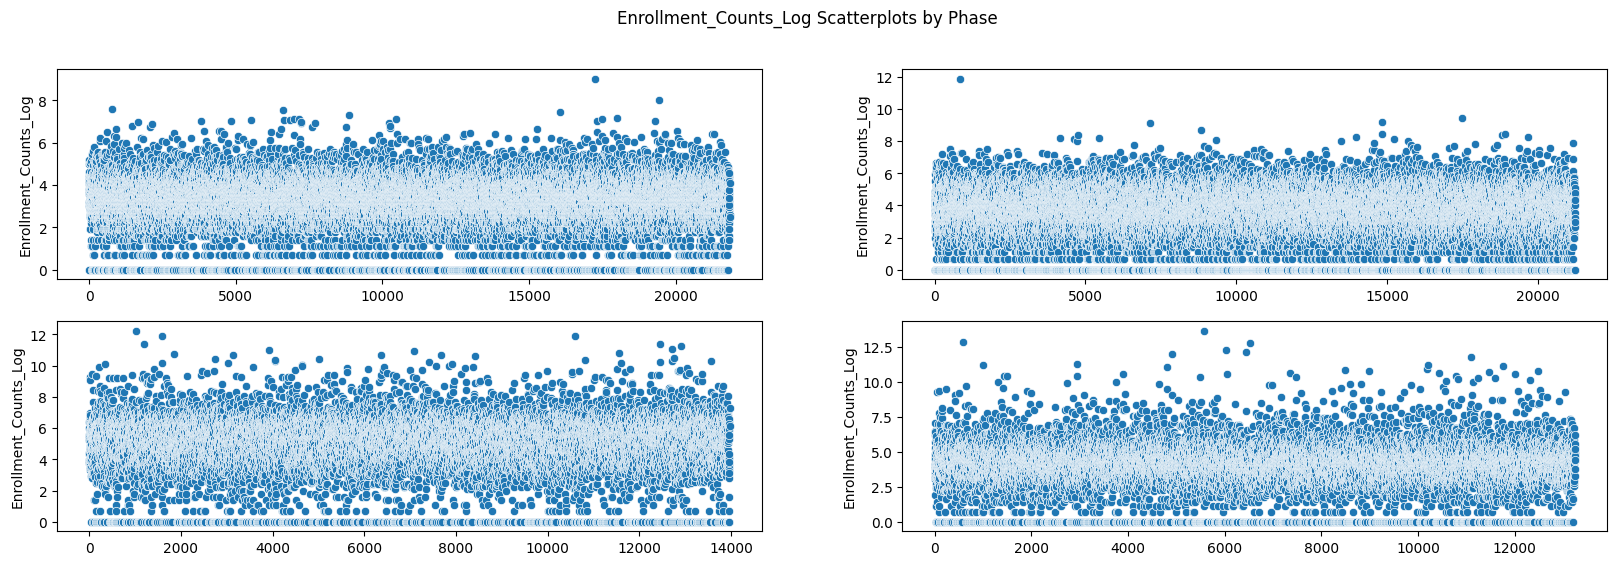

In [ ]:
plt.fig, ax = plt.subplots(figsize=(20, 6), nrows = 2, ncols = 2)

sns.scatterplot(df1['Enrollment_Counts_Log'], ax=ax[0,0])
sns.scatterplot(df2['Enrollment_Counts_Log'], ax=ax[0,1])
sns.scatterplot(df3['Enrollment_Counts_Log'], ax=ax[1,0])
sns.scatterplot(df4['Enrollment_Counts_Log'], ax=ax[1,1])

plt.fig.suptitle('Enrollment_Counts_Log Scatterplots by Phase')

### Enrollment_Categ
- See Enrollment Plot as Continues below. Better Plot as continues (BoxPlot)

df2-Phase 2:
Enrollment_Categ vs Study Status

p-value: 0.0 < 0.05

------------------------------------------------------------------------------------------------------------

df2-Phase 2:
Enrollment_Categ vs Study Status (Termination)



Study_Status_Bin,COMPLETED,TERMINATED
Enrollment_Categ,,
0–44,5025,3578
45–144539,7618,761


                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                16982
Model:                          Logit   Df Residuals:                    16980
Method:                           MLE   Df Model:                            1
Date:                Sat, 04 Oct 2025   Pseudo R-squ.:                  0.1305
Time:                        01:10:21   Log-Likelihood:                -8391.7
converged:                       True   LL-Null:                       -9650.9
Covariance Type:            nonrobust   LLR p-value:                     0.000
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -0.3396      0.022    -15.525      0.000      -0.382      -0.297
Enrollment_Categ    -1.9640      0.044    -44.778      0.000      -2.050      -1.878


df2-Phase2: Enrollment_Cat

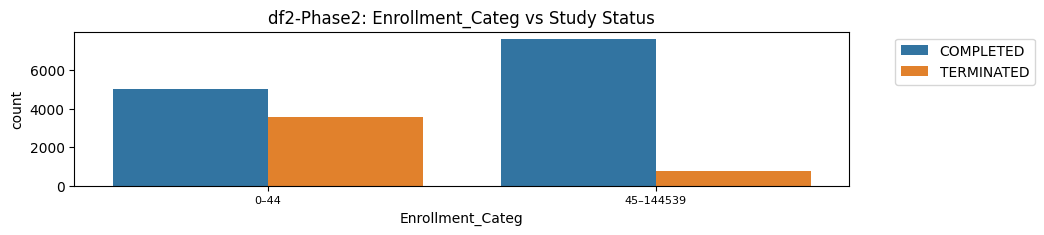

In [ ]:
chi2_fun("Enrollment_Categ", dfi, i)
#### log_fun
Enrollment_Categ = log_fun('Enrollment_Categ', dfi, i, 'bin', True, 0)

#### Format

In [ ]:
Enrollemnt_Counts_aic = fun_compare(i, Enrollment_Counts = Enrollment_Counts[0], 
                                    Enrollment_Counts_Log = Enrollment_Counts_Log[0], 
                                    )
Enrollemnt_Counts_aic

,Enrollment_Counts,Enrollment_Counts_Log,AIC_min
df2,,,
Enrollment_Counts,[17532.0],[13210.0],Enrollment_Counts_Log


In [ ]:
dfi = dfi.drop(columns = ['Enrollment_Counts', 'Enrollment_Categ'], axis = 1)

#### Enrollment Outliers

Text(0.5, 0.98, 'Phase 2 Enrollment_Counts_Log')

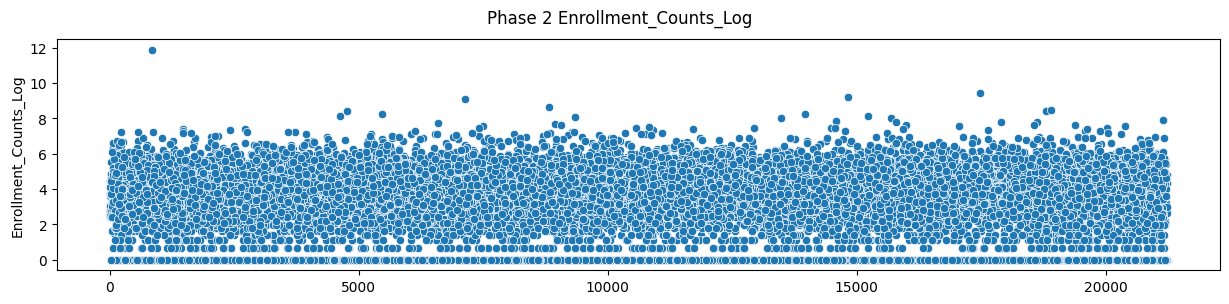

In [ ]:
plt.fig, ax = plt.subplots(figsize=(15, 3))

sns.scatterplot(dfi['Enrollment_Counts_Log'],)

plt.fig.suptitle(f'Phase {i} Enrollment_Counts_Log')

# AIC

In [ ]:
aics = [
        Adverse_Counts_aic, Adverse_System_Counts_aic,
        Arm_Counts_aic,
        City_Counts_aic, Country_Counts_aic, Continent_Counts_aic, 
        Enrollemnt_Counts_aic
        ]

In [ ]:
for idx in range(len(aics)):
    aic = aics[idx]
    for col in aic.columns:
        if '_' in col:
            new_col = col.split('_')[-1]
            aic.rename(columns = {col: new_col}, inplace = True)
    aics[idx] = aic
# aics[-2] # Example

AIC_Total = pd.concat(aics, ignore_index = False)
AIC_Total = AIC_Total.rename(columns = {'min' : 'AIC_Min'})
AIC_Total = AIC_Total.reindex(labels = ['Counts', 'Log', 'Categ', 'Bin', 'AIC_Min'], axis = 1)
AIC_Total

,Counts,Log,Categ,Bin,AIC_Min
df2,,,,,
Adverse_Counts,[19068.0],[18943.0],NaN,[19240.0],Adverse_Counts_Log
Adverse_System_Counts,[19228.0],[19228.0],NaN,NaN,Adverse_System_Counts
Arm_Counts,[19126.0],[19126.0],NaN,NaN,Arm_Counts
City_Counts,[19258.0],[19163.0],[19212.0],NaN,City_Counts_Log
Country_Counts,[19302.0],[19254.0],[19294.0],NaN,Country_Counts_Log
Continent_Counts,[19299.0],[19282.0],[19305.0],NaN,Continent_Counts_Log
Enrollment_Counts,[17532.0],[13210.0],NaN,NaN,Enrollment_Counts_Log


# P_Value/ CL : Univariable 

In [ ]:
p_cols = dfi.columns.tolist()
# cls df
cl_vars = p_cols.copy()
cl_list = [globals()[var][2][1:] for var in cl_vars if var!= 'Study_Status_Bin']  
cls = pd.concat(cl_list, axis = 0).reset_index(drop = False)
cls = cls.rename(columns = {'index': f'Variable', 0: f'df{i}-Lower_CL', 1: f'df{i}-Upper_CL'})
cls[[f'df{i}-Lower_CL', f'df{i}-Upper_CL']] = cls[[f'df{i}-Lower_CL', f'df{i}-Upper_CL']].round(3)

# p_values df
p_vars = p_cols.copy()
p_list = [globals()[var][1][0][1:] for var in p_vars if var!= 'Study_Status_Bin']   
# [1][0][1:] Explain:
# [1] --> index = 1 of function's returns = p_value , 
# [0] --> gives back the unique element of list as a df, 
# [1:] --> excludes 1st row which is the constant.
p_values = pd.concat(p_list, axis = 0).reset_index(drop = False)
p_values = p_values.rename(columns = {'index': f'Variable', 0: f'df{i}-p-value'})
p_values[f'df{i}-p-value'] = p_values[f'df{i}-p-value'].round(3)

# p_cl df
p_cl = pd.merge(left = p_values, right = cls, how = 'inner', on = f'Variable')
p_cl[f'df{i}-Stat_Sig'] = np.where(
     (p_cl[f'df{i}-p-value'] < 0.05), 
     'Stat_Sig', '-'
)
p_cl.index.name = f'df{i}'
p_cl = p_cl.drop_duplicates()
p_cl

,Variable,df2-p-value,df2-Lower_CL,df2-Upper_CL,df2-Stat_Sig
df2,,,,,
0,FEMALE,0.001,-0.368,-0.096,Stat_Sig
1,MALE,0.865,-0.161,0.192,-
2,ADULT,0.121,-0.326,0.038,-
3,OLDER_ADULT,0.000,0.443,0.673,Stat_Sig
4,Funder_Industry_Bin,0.000,-0.299,-0.159,Stat_Sig
...,...,...,...,...,...
89,Europe,0.000,-0.245,-0.081,Stat_Sig
90,North America,0.000,0.146,0.305,Stat_Sig
91,Continent_Counts_Log,0.000,-0.122,-0.052,Stat_Sig


In [ ]:
dfi.columns.to_list()

['Study_Status_Bin',
 'Sex_List',
 'Age_List',
 'Funder_Industry_Bin',
 'Intervention_Type_List',
 'Intervention_Route_List',
 'Placebo_Bin',
 'Standard_Care_Bin',
 'Healthy_Bin',
 'Conditions_Detail_List',
 'Adverse_List',
 'Adverse_Counts_Log',
 'Adverse_System_List',
 'Adverse_System_Counts_Log',
 'Allocation_List',
 'Intervention_Model_List',
 'Masking_List',
 'Masking_Detail_List',
 'Primary_Purpose_List',
 'Arm_Counts_Log',
 'Country_Counts_Log',
 'Continents_List',
 'Continent_Counts_Log',
 'City_Counts_Log',
 'Enrollment_Counts_Log']

# Save p_values

In [ ]:
def save_pvalue_pickle(p_cl, i):
    
    if i == 1:
        path = r".\p_values\p_cl1_vizual.pkl"
    elif i == 2:
        path = r".\p_values\p_cl2_vizual.pkl"
    elif i == 3:
        path = r".\p_values\p_cl3_vizual.pkl"
    elif i == 4:
        path = r".\p_values\p_cl4_vizual.pkl"

    return p_cl.to_pickle(path)

save_pvalue_pickle(p_cl, i)
